In [26]:
# NEW CODE
import numpy as np
import importlib
import pandas as pd
import os
import random
import joblib
from pythermalcomfort.models import pmv_ppd_iso
import torch
import Hvac_predict_script

importlib.reload(Hvac_predict_script)
from Hvac_predict_script import predict_Tin_sequence_full, LSTMWithFuture, CNNLSTMWithFuture

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)

test_start = pd.Timestamp('2023-01-22')
test_end = pd.Timestamp('2023-01-29')

df = dfs[0].copy()
relevant_cols = ['total_energy', 'hvac_energy', 'Tin', 'Tout', 'RH']
df_relevant = df.copy()

nan_at_end = df_relevant[relevant_cols].iloc[::-1].isna().cumprod().iloc[::-1].astype(bool)
rows_to_drop = nan_at_end.any(axis=1)
df_cleaned = df_relevant[~rows_to_drop].copy()
sensor_nan_rows = df_cleaned[['Tin', 'Tout', 'RH']].isna().any(axis=1)
df_cleaned.loc[
    (df_cleaned['total_energy'] == 0.0) & sensor_nan_rows,
    'total_energy'
] = np.nan
df_cleaned[['total_energy', 'Tin', 'Tout', 'RH']] = df_cleaned[
    ['total_energy', 'Tin', 'Tout', 'RH']
].interpolate(method='linear', limit_direction='both')
# df.drop(index=df[df['total_energy'] == 0.0].index, inplace=True)
df = df_cleaned.copy()

df['T_diff'] = (df['Tout'] - df['Tin']).bfill()
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month'] = df.index.month

# results.append({
#         'timestamp': df_test.index[idx],
#         'Tin_pred': Tin_pred,
#         'Tin_true': row['Tin'],
#         'hvac_mode': hvac_mode,
#         'Tin_target': row['Tin_target'],
#         'RH_pred': RH_pred,
#         'RH_true': row['RH'],
# })
tin_model = LSTMWithFuture(input_size=3, hidden_size=128, num_layers=2)
tin_model.load_state_dict(torch.load('best_model_tin.pt'))
rh_model = CNNLSTMWithFuture(input_size=7, hidden_size=128, num_layers=2)
rh_model.load_state_dict(torch.load('best_model_rh.pt'))

scaler_tin = joblib.load('scaler_tin.pkl')
scaler_rh = joblib.load('scaler_rh.pkl')

df['Tin_target']  = df['Tin'].shift(-1).dropna()          
df['is_test'] = (df.index >= test_start) & (df.index <= test_end)
df['RH_target'] = df['RH'].shift(-1)

df['hvac_mode'] = 0 
on_mask = df['hvac_energy'] > 0
nonzero_power = df.loc[on_mask, 'hvac_energy']
bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values

df_test = df[df['is_test']].copy()
df_encoded_test = df_test.copy()
df_encoded_test = df_encoded_test.join(pd.get_dummies(df_test['hvac_mode'], prefix='hvac'))

rf_model = joblib.load('best_model_rf.pkl')

import random

def generate_schedule():
    return [random.choice([0, 1, 2]) for _ in range(96)]

def calculate_overall_comfort(list_tin, list_rh):
    ppd_values = []
    for tin, rh in zip(list_tin, list_rh):
        comfort = pmv_ppd_iso(
            tdb=tin,
            tr=tin,     
            vr=0.1,     
            rh=rh,
            met=1.1,    
            clo=1.0     
        )
        if comfort['ppd'] is None:
            print(tin)
            ppd_values.append(75)  
        else:
            ppd_values.append(comfort['ppd'])  
    return ppd_values  

def evaluate_schedule(schedule = None):
    if schedule is None:
        schedule = generate_schedule()

    results = predict_Tin_sequence_full(        
        df_test=df_encoded_test,  
        window_start_idx=10,       
        lstm_model=tin_model,     
        rf_model=rf_model,  
        tin_scaler=scaler_tin,   
        rh_model=rh_model,        
        rh_scaler=scaler_rh,     
        n_steps=96,
        hvac_schedule=schedule             
    )
    
    tin_pred = results['Tin_pred'].values
    rh_pred = results['RH_pred'].values
    ppd_list = calculate_overall_comfort(tin_pred, rh_pred)  
    
    avg_ppd = 100 - np.mean(ppd_list)
    print(f"Average comfort percentage: {avg_ppd:.2f}")
    # switches = count_switches(schedule)
    # if switches > 20:
    #     avg_ppd += 0.5  # soft penalty
    
    # return avg_ppd

def count_switches(schedule):
    return sum(1 for i in range(1, len(schedule)) if schedule[i] != schedule[i-1])

evaluate_schedule()


Average comfort percentage: 86.53


In [27]:
import pygad
import numpy as np

hvac_choices = [0, 1, 2]

def fitness_func(ga_instance, solution, solution_idx):
    schedule = [int(x) for x in solution]  
    results = predict_Tin_sequence_full(
        df_test=df_encoded_test,
        window_start_idx=100,
        lstm_model=tin_model,
        rf_model=rf_model,
        tin_scaler=scaler_tin,
        rh_model=rh_model,
        rh_scaler=scaler_rh,
        n_steps=96,
        hvac_schedule=schedule
    )
    tin_pred = results['Tin_pred'].values
    rh_pred = results['RH_pred'].values
    list_rh = df_test['RH'].iloc[10:10 + 96].tolist()

    ppd_list = calculate_overall_comfort(tin_pred, rh_pred)
    avg_ppd = np.nanmean(ppd_list)
    
    return 100 - avg_ppd  

gene_space = hvac_choices
num_genes = 96

ga_instance = pygad.GA(
    num_generations=15,
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=num_genes,
    gene_space=gene_space,
    parent_selection_type="tournament",
    keep_parents=4,
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=15,
    stop_criteria=["saturate_30"]
)

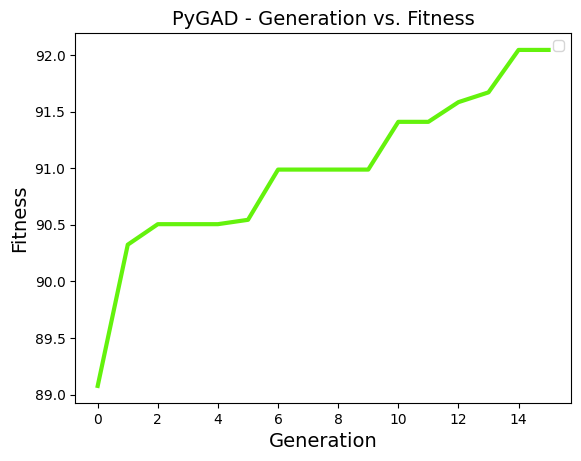

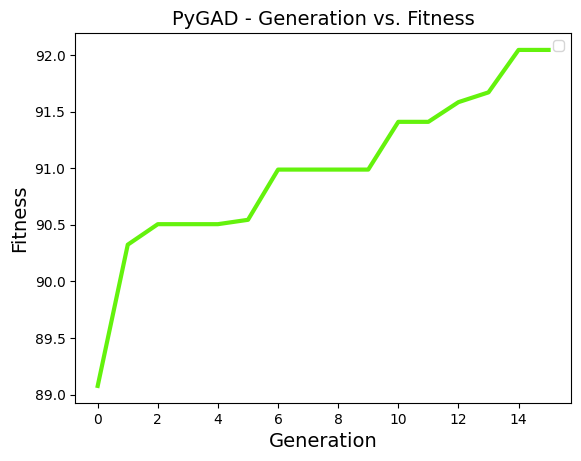

In [8]:
ga_instance.run()
ga_instance.plot_fitness()

In [9]:
solution, fitness, _ = ga_instance.best_solution()
best_schedule = [int(x) for x in solution]
print("Best schedule:", best_schedule)
print("Best avg comfort score (100 - PPD):", fitness)

Best schedule: [1, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 0, 2, 0, 2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 0, 2, 1, 2, 1, 1, 2, 2, 1, 2, 2, 1, 0, 1, 1, 2, 0, 1, 2, 0, 1, 1, 2, 1, 2, 0, 1, 1, 0, 0, 1, 0, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 0, 1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 0, 1, 2, 1, 1, 2, 1, 0, 0]
Best avg comfort score (100 - PPD): 91.803125


In [ ]:
def evaluate_ground_truth_comfort(df_test, window_start_idx):
    list_tin = df_test['Tin'].iloc[window_start_idx:window_start_idx + 96].tolist()
    list_rh = df_test['RH'].iloc[window_start_idx:window_start_idx + 96].tolist()

    ppd_list = calculate_overall_comfort(list_tin, list_rh)
    avg_ppd = np.nanmean(ppd_list)

    comfort_score = 100 - avg_ppd
    print("Ground Truth Comfort Score (100 - avg PPD):", round(comfort_score, 2))

    return comfort_score

evaluate_ground_truth_comfort(df_encoded_test, window_start_idx=10)


Ground Truth Comfort Score (100 - avg PPD): 77.54


np.float64(77.54062499999999)

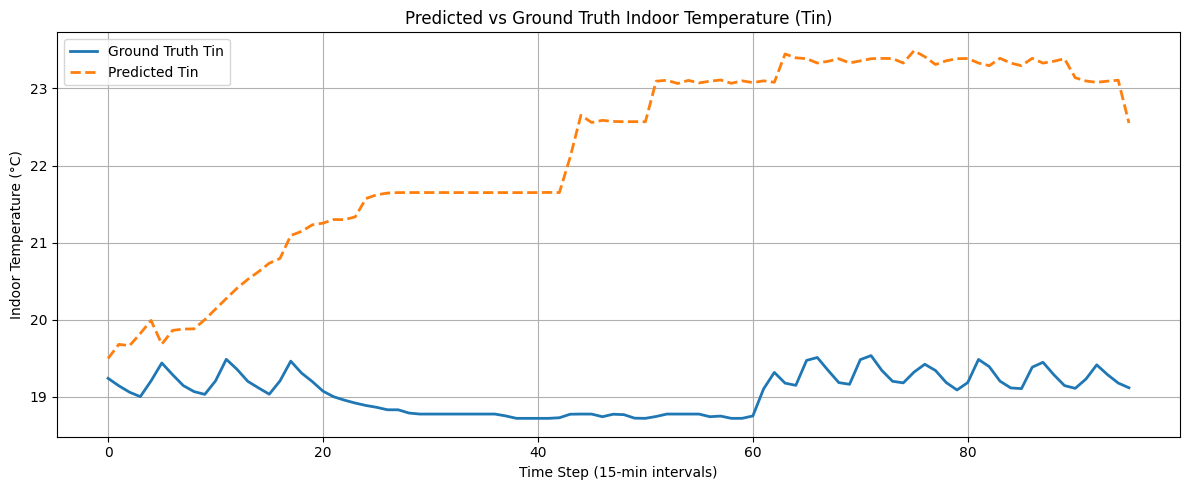

Ground Truth Comfort Score (100 - avg PPD): 77.87


In [ ]:
import matplotlib.pyplot as plt
# print(test)
results = predict_Tin_sequence_full(        
    df_test=df_encoded_test,  
    window_start_idx=10,       
    lstm_model=tin_model,     
    rf_model=rf_model,  
    tin_scaler=scaler_tin,   
    rh_model=rh_model,        
    rh_scaler=scaler_rh,     
    n_steps=96,
    hvac_schedule=best_schedule             
)

def plot_tin_prediction_vs_ground_truth(results):
    predicted_tin = results['Tin_pred'].values

    ground_truth_tin = results['Tin_target'].values

    time_steps = range(96)

    plt.figure(figsize=(12, 5))
    plt.plot(time_steps, ground_truth_tin, label='Ground Truth Tin', linewidth=2)
    plt.plot(time_steps, predicted_tin, label='Predicted Tin', linestyle='--', linewidth=2)
    plt.xlabel("Time Step (15-min intervals)")
    plt.ylabel("Indoor Temperature (°C)")
    plt.title("Predicted vs Ground Truth Indoor Temperature (Tin)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_tin_prediction_vs_ground_truth(results)
list_tin = results['Tin_target'].values
list_rh = results['RH_true'].values
ppd_list = calculate_overall_comfort(list_tin, list_rh)
avg_ppd = np.nanmean(ppd_list)

comfort_score = 100 - avg_ppd
print("Ground Truth Comfort Score (100 - avg PPD):", round(comfort_score, 2))



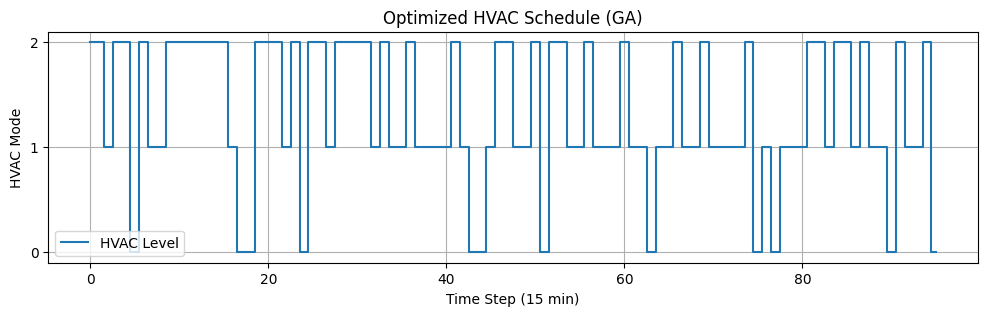

In [7]:
plt.figure(figsize=(12, 3))
plt.step(range(96), best_schedule, where='mid', label='HVAC Level')
plt.yticks([0, 1, 2])
plt.xlabel("Time Step (15 min)")
plt.ylabel("HVAC Mode")
plt.title("Optimized HVAC Schedule (GA)")
plt.grid(True)
plt.legend()
plt.show()

In [28]:
from pyomo.environ import ConcreteModel, Var, Objective, Constraint, SolverFactory, RangeSet, Binary, value, maximize
import numpy as np

pv_data = pd.read_csv('datasets/pv_data/shifted_pv_data.csv')

start_time = df_encoded_test.index[100]
end_time = start_time + pd.Timedelta(minutes=15 * 95)

pv_data['timestamps'] = pd.to_datetime(pv_data["timestamps"])  # just in case
pv_window = pv_data[
    (pv_data["timestamps"] >= start_time) &
    (pv_data["timestamps"] <= end_time)
].copy()


pv_forecast = (pv_window["total_energy"] > 0.05).astype(int).tolist()
time_steps = 96
lambda_comfort = 0.0  
# pv_forecast = np.random.choice([0, 1], size=time_steps).tolist()  

model = ConcreteModel()
model.T = RangeSet(0, time_steps - 1)
model.mode_0 = Var(model.T, domain=Binary)
model.mode_1 = Var(model.T, domain=Binary)
model.mode_2 = Var(model.T, domain=Binary)

def mode_constraint_rule(model, t):
    return model.mode_0[t] + model.mode_1[t] + model.mode_2[t] == 1
model.mode_constraint = Constraint(model.T, rule=mode_constraint_rule)

def objective_rule(model):
       return sum(
        (model.mode_1[t] + model.mode_2[t]) * (pv_forecast[t] - 0.25 * (1 - pv_forecast[t]))
        for t in model.T
    )


# model.objective = Objective(rule=objective_rule, sense=maximize)

# solver = SolverFactory('cbc')
# results = solver.solve(model, tee=False)

# hvac_schedule = []
# for t in model.T:
#     if value(model.mode_2[t]) == 1:
#         hvac_schedule.append(2)
#     elif value(model.mode_1[t]) == 1:
#         hvac_schedule.append(1)
#     else:
#         hvac_schedule.append(0)

# results = predict_Tin_sequence_full(
#     df_test=df_encoded_test,
#     window_start_idx=100,
#     lstm_model=tin_model,
#     rf_model=rf_model,
#     tin_scaler=scaler_tin,
#     rh_model=rh_model,
#     rh_scaler=scaler_rh,
#     n_steps=96,
#     hvac_schedule=hvac_schedule
# )
# Tin_pred = results['Tin_pred'].values
# RH_pred = results['RH_pred'].values
# ppd_list = calculate_overall_comfort(Tin_pred, RH_pred)
# avg_ppd = np.nanmean(ppd_list)
# avg_comfort = 100 - avg_ppd  


comfort_threshold = 80
min_on_steps = 0
max_iterations = 10

for attempt in range(max_iterations):
    model.objective = Objective(rule=objective_rule, sense=maximize)

    solver = SolverFactory('cbc')
    results = solver.solve(model, tee=False)

    hvac_schedule = []
    for t in model.T:
        if value(model.mode_2[t]) == 1:
            hvac_schedule.append(2)
        elif value(model.mode_1[t]) == 1:
            hvac_schedule.append(1)
        else:
            hvac_schedule.append(0)

    results = predict_Tin_sequence_full(
        df_test=df_encoded_test,
        window_start_idx=100,
        lstm_model=tin_model,
        rf_model=rf_model,
        tin_scaler=scaler_tin,
        rh_model=rh_model,
        rh_scaler=scaler_rh,
        n_steps=96,
        hvac_schedule=hvac_schedule
    )
    Tin_pred = results['Tin_pred'].values
    RH_pred = results['RH_pred'].values
    ppd_list = calculate_overall_comfort(Tin_pred, RH_pred)
    comfort_list = [100 - ppd for ppd in ppd_list]

    all_above = all(c >= comfort_threshold for c in comfort_list)

    if all_above:
        print(f"✅ Schedule OK at attempt {attempt+1} — all comfort ≥ {comfort_threshold}%")
        break
    else:
        print(f"❌ Schedule rejected at attempt {attempt+1} — some comfort < {comfort_threshold}%")
        min_on_steps += 4  

# if avg_comfort >= 80:
#     print(f"✅ Optimal schedule found with average comfort: {avg_comfort:.2f}%")
# else:
#     print(f"❌ Comfort too low: {avg_comfort:.2f}%. Need to rerun with stricter constraints or comfort model in-loop.")

print("HVAC Schedule:", hvac_schedule)

❌ Schedule rejected at attempt 1 — some comfort < 80%
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.ScalarObjective'>). This is
usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
❌ Schedule rejected at attempt 2 — some comfort < 80%
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.ScalarObjective'>). This is
usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
❌ Schedule rejected at attempt 3 — some comfort < 80%
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.ScalarObjective'>). This is
usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
❌ Schedule rejected at attempt 

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\814489285.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start=start_time, periods=96, freq='15T')


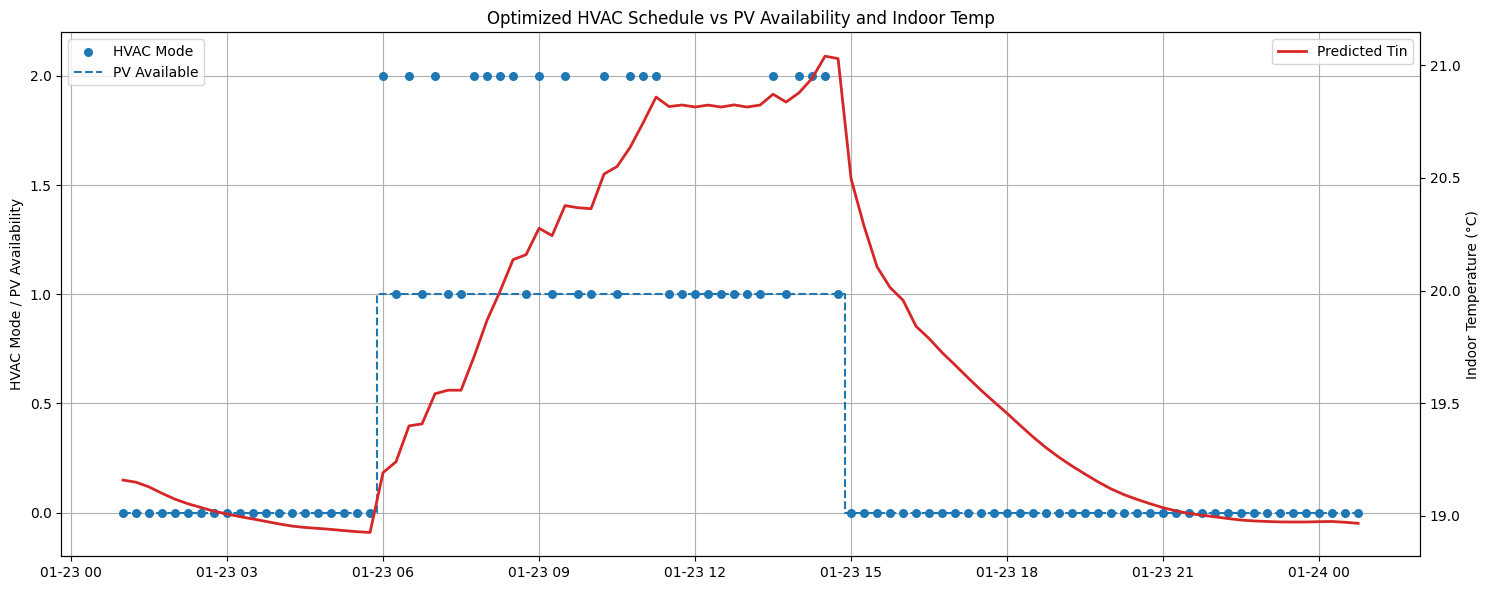

In [17]:
timestamps = pd.date_range(start=start_time, periods=96, freq='15T')
import matplotlib.pyplot as plt
# Create a DataFrame to plot
df_plot = pd.DataFrame({
    "timestamp": timestamps,
    "HVAC_mode": hvac_schedule,
    "PV_available": pv_forecast,
    "Tin_pred": Tin_pred
})
df_plot.set_index("timestamp", inplace=True)

# Plotting
fig, ax1 = plt.subplots(figsize=(15, 6))

# HVAC & PV (left Y-axis)
ax1.scatter(df_plot.index, df_plot["HVAC_mode"], label="HVAC Mode", color="tab:blue", s=30, zorder=3)
ax1.step(df_plot.index, df_plot["PV_available"], label="PV Available", where='mid', linestyle='--', linewidth=1.5)
ax1.set_ylabel("HVAC Mode / PV Availability")
ax1.set_ylim(-0.2, 2.2)
ax1.legend(loc="upper left")
ax1.grid(True)

# Temperature (right Y-axis)
ax2 = ax1.twinx()
ax2.plot(df_plot.index, df_plot["Tin_pred"], label="Predicted Tin", color="tab:red", linewidth=2)
ax2.set_ylabel("Indoor Temperature (°C)")
ax2.legend(loc="upper right")

# Title and X formatting
plt.title("Optimized HVAC Schedule vs PV Availability and Indoor Temp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print(ppd_list)

[np.float64(20.9), np.float64(21.0), np.float64(21.2), np.float64(21.4), np.float64(21.7), np.float64(21.8), np.float64(22.0), np.float64(22.2), np.float64(22.3), np.float64(22.4), np.float64(22.6), np.float64(22.7), np.float64(22.8), np.float64(22.9), np.float64(23.0), np.float64(23.1), np.float64(23.1), np.float64(23.2), np.float64(23.3), np.float64(23.4), np.float64(21.2), np.float64(20.8), np.float64(19.5), np.float64(19.4), np.float64(18.4), np.float64(18.2), np.float64(18.3), np.float64(17.2), np.float64(16.0), np.float64(15.1), np.float64(14.2), np.float64(14.1), np.float64(13.4), np.float64(13.6), np.float64(12.8), np.float64(12.8), np.float64(12.9), np.float64(12.1), np.float64(11.9), np.float64(11.4), np.float64(10.8), np.float64(10.3), np.float64(10.5), np.float64(10.5), np.float64(10.6), np.float64(10.6), np.float64(10.7), np.float64(10.7), np.float64(10.8), np.float64(10.8), np.float64(10.5), np.float64(10.6), np.float64(10.4), np.float64(10.0), np.float64(9.5), np.float64

In [29]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from Hvac_predict_script import predict_next_step

class HVACEnv(gym.Env):
    def __init__(self, df_test, df_pv, window_start_idx, tin_model, rf_model, rh_model,
                 scaler_tin, scaler_rh, comfort_fn, forecast_fn):
        super(HVACEnv, self).__init__()

        self.df_test = df_test.copy()
        self.df_pv = df_pv.copy()
        self.start_idx = window_start_idx
        self.tin_model = tin_model
        self.rf_model = rf_model
        self.rh_model = rh_model
        self.scaler_tin = scaler_tin
        self.scaler_rh = scaler_rh
        self.forecast_fn = forecast_fn
        self.comfort_fn = comfort_fn

        self.time_steps = 96
        self.action_space = spaces.Discrete(3) 

        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0]),
            high=np.array([95, 1, 50, 100]),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed) 
        self.current_step = 0
        self.schedule = []

        self.start_time = self.df_test.index[self.start_idx]
        self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")

        self.pv_forecast = (self.df_pv.loc[self.timestamps, "total_energy"] > 0.05).astype(int).tolist()

        self.Tin = [self.df_test.iloc[self.start_idx]["Tin"]] 
        self.RH = [self.df_test.iloc[self.start_idx]["RH"]]   

        return self._get_obs(), {}

    def _get_obs(self):
        t = min(self.current_step, self.time_steps - 1)
        obs = np.array([
            t,
            self.pv_forecast[t],
            self.Tin[-1],
            self.RH[-1]
        ], dtype=np.float32)
        return obs

    def step(self, action):
        self.schedule.append(action)
        self.current_step += 1

        # Forecast next Tin and RH from current schedule
        Tin_next, RH_next = predict_next_step(
            df_test=self.df_test,
            current_idx=self.start_idx + self.current_step,
            schedule=self.schedule,
            lstm_model=self.tin_model,
            rf_model=self.rf_model,
            tin_scaler=self.scaler_tin,
            rh_model=self.rh_model,
            rh_scaler=self.scaler_rh
        )

        self.Tin.append(Tin_next)
        self.RH.append(RH_next)

        comfort = 100 - self.comfort_fn([Tin_next], [RH_next])[0]  # PMV -> comfort %

        reward = 0
        if comfort >= 80:
            if self.pv_forecast[self.current_step - 1] and action > 0:
                reward += 1  # good: HVAC ON with PV
            elif action > 0:
                reward += 0.2  # acceptable: grid use for comfort
            else:
                reward -= 1  # discomfort risk due to HVAC off
        else:
            reward -= 3  # strong penalty for comfort violation

        terminated = self.current_step >= self.time_steps
        truncated = False
        info = {"comfort": comfort, "Tin": Tin_next, "RH": RH_next}
        return self._get_obs(), reward, terminated, truncated, info


In [30]:
pv_data['timestamps'] = pd.to_datetime(pv_data['timestamps'])  # ensure datetime type
pv_data.set_index('timestamps', inplace=True)

In [35]:
from stable_baselines3 import PPO

env = HVACEnv( 
    df_test=df_encoded_test,
    df_pv=pv_data,
    window_start_idx=100,  # or any index for the start of the 24h window
    tin_model=tin_model,
    rf_model=rf_model,
    rh_model=rh_model,
    scaler_tin=scaler_tin,
    scaler_rh=scaler_rh,
    comfort_fn=calculate_overall_comfort,  # function: returns ppd_list
    forecast_fn=predict_Tin_sequence_full  )

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100_000)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 96       |
|    ep_rew_mean     | -112     |
| time/              |          |
|    fps             | 38       |
|    iterations      | 1        |
|    time_elapsed    | 52       |
|    total_timesteps | 2048     |
---------------------------------


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


...

-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 96            |
|    ep_rew_mean          | 47.8          |
| time/                   |               |
|    fps                  | 30            |
|    iterations           | 47            |
|    time_elapsed         | 3190          |
|    total_timesteps      | 96256         |
| train/                  |               |
|    approx_kl            | 0.00019290298 |
|    clip_fraction        | 0.000879      |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.00696      |
|    explained_variance   | 1             |
|    learning_rate        | 0.0003        |
|    loss                 | 0.00559       |
|    n_updates            | 460           |
|    policy_gradient_loss | -0.00052      |
|    value_loss           | 0.0584        |
-------------------------------------------


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 96            |
|    ep_rew_mean          | 47.8          |
| time/                   |               |
|    fps                  | 30            |
|    iterations           | 48            |
|    time_elapsed         | 3259          |
|    total_timesteps      | 98304         |
| train/                  |               |
|    approx_kl            | 0.00043856422 |
|    clip_fraction        | 0.00186       |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.00465      |
|    explained_variance   | 0.999         |
|    learning_rate        | 0.0003        |
|    loss                 | 0.0101        |
|    n_updates            | 470           |
|    policy_gradient_loss | -0.000744     |
|    value_loss           | 0.101         |
-------------------------------------------


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 96           |
|    ep_rew_mean          | 47.8         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 49           |
|    time_elapsed         | 3328         |
|    total_timesteps      | 100352       |
| train/                  |              |
|    approx_kl            | 0.0008223726 |
|    clip_fraction        | 0.00132      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.00258     |
|    explained_variance   | 0.999        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0208       |
|    n_updates            | 480          |
|    policy_gradient_loss | -0.0011      |
|    value_loss           | 0.0985       |
------------------------------------------


In [ ]:
obs = env.reset()
done = False
while not done:
    action, _ = model.predict(obs)
    obs, reward, done, info = env.step(action)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2336050300.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time_axis = pd.date_range(start=env.df_test.index[env.start_idx], periods=n, freq="15T")


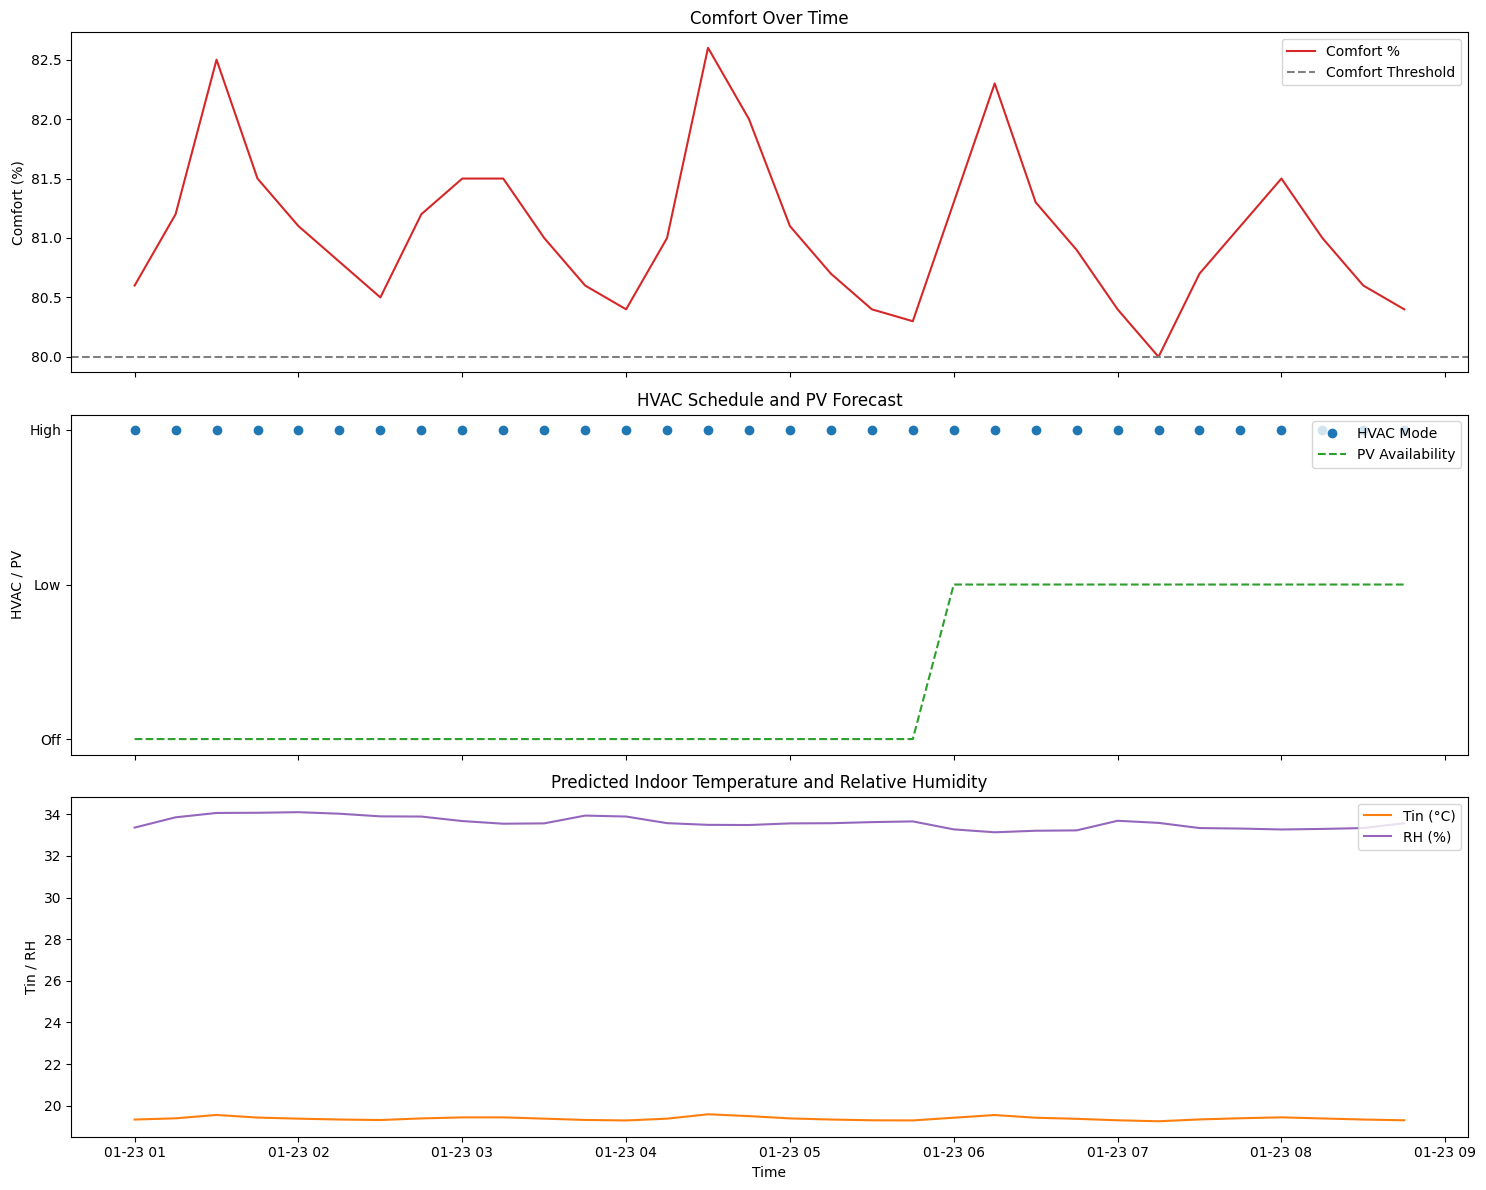

In [36]:
import matplotlib.pyplot as plt

n = len(env.schedule)
time_axis = pd.date_range(start=env.df_test.index[env.start_idx], periods=n, freq="15T")
comfort_list = [100 - c for c in calculate_overall_comfort(env.Tin[1:n+1], env.RH[1:n+1])]

fig, axs = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Comfort
axs[0].plot(time_axis, comfort_list, color='tab:red', label='Comfort %')
axs[0].axhline(80, linestyle="--", color="gray", label="Comfort Threshold")
axs[0].set_ylabel("Comfort (%)")
axs[0].legend(loc="upper right")
axs[0].set_title("Comfort Over Time")

# HVAC and PV
axs[1].plot(time_axis, env.schedule, label="HVAC Mode", color='tab:blue', marker='o', linestyle='None')
axs[1].plot(time_axis, env.pv_forecast[:n], label="PV Availability", color='tab:green', linestyle='--')
axs[1].set_ylabel("HVAC / PV")
axs[1].set_yticks([0, 1, 2])
axs[1].set_yticklabels(['Off', 'Low', 'High'])
axs[1].legend(loc="upper right")
axs[1].set_title("HVAC Schedule and PV Forecast")

# Tin & RH
axs[2].plot(time_axis, env.Tin[1:n+1], label="Tin (°C)", color='tab:orange')
axs[2].plot(time_axis, env.RH[1:n+1], label="RH (%)", color='tab:purple')
axs[2].set_ylabel("Tin / RH")
axs[2].legend(loc="upper right")
axs[2].set_title("Predicted Indoor Temperature and Relative Humidity")

plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from pythermalcomfort.models import pmv_ppd_iso
import pyomo.environ as pyo
import numpy as np
import importlib
import pandas as pd
import os
import random
import joblib
from pythermalcomfort.models import pmv_ppd_iso
import torch
import Hvac_predict_script

importlib.reload(Hvac_predict_script)
from Hvac_predict_script import predict_Tin_sequence_full, LSTMWithFuture, CNNLSTMWithFuture

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('with_comfort.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)
df = dfs[0].copy()

tin_model = LSTMWithFuture(input_size=3, hidden_size=128, num_layers=2)
tin_model.load_state_dict(torch.load('best_model_tin.pt'))
rh_model = CNNLSTMWithFuture(input_size=7, hidden_size=128, num_layers=2)
rh_model.load_state_dict(torch.load('best_model_rh.pt'))

scaler_tin = joblib.load('scaler_tin.pkl')
scaler_rh = joblib.load('scaler_rh.pkl')

test_start = pd.Timestamp('2023-01-22')
test_end = pd.Timestamp('2023-01-29')

df['Tin_target']  = df['Tin'].shift(-1).dropna()          
df['is_test'] = (df.index >= test_start) & (df.index <= test_end)
df['RH_target'] = df['RH'].shift(-1)
df['T_diff'] = (df['Tout'] - df['Tin']).bfill()
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month'] = df.index.month

df['hvac_mode'] = 0 
on_mask = df['pump_energy'] > 0
nonzero_power = df.loc[on_mask, 'pump_energy']
bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values

df_test = df[df['is_test']].copy()
df_encoded_test = df_test.copy()
df_encoded_test = df_encoded_test.join(pd.get_dummies(df_test['hvac_mode'], prefix='hvac'))

rf_model = joblib.load('best_model_rf.pkl')


In [5]:
df_encoded_test.head()

,total_energy,pump_energy,hvac_energy,Tin,Tout,RH,month,PMV,PPD,Overall_Comfort,Tin_target,is_test,RH_target,hvac_mode,hvac_0,hvac_1,hvac_2
timestamp,,,,,,,,,,,,,,,,,
2023-01-22 00:00:00,974.581572,0.000000,0.000000,19.289259,0.536000,32.000000,1,-0.84,20.0,80.0,19.172222,True,31.930000,0,True,False,False
2023-01-22 00:15:00,393.681751,0.000000,0.000000,19.172222,0.512000,31.930000,1,-0.87,21.0,79.0,19.139259,True,31.520000,0,True,False,False
2023-01-22 00:30:00,187.689159,97.278886,97.285274,19.139259,0.528000,31.520000,1,-0.88,21.4,78.6,19.385556,True,31.500000,2,False,False,True
2023-01-22 00:45:00,118.989408,41.291959,41.299460,19.385556,0.500000,31.500000,1,-0.82,19.3,80.7,19.448889,True,31.716667,1,False,True,False
2023-01-22 01:00:00,75.692804,0.000000,0.000000,19.448889,0.512667,31.716667,1,-0.81,18.8,81.2,19.296667,True,32.000000,0,True,False,False


In [ ]:

# -------------------------
# Config
# -------------------------
COMFORT_MIN = 75.0   # % comfort (i.e., 100 - PPD >= 75)
PMV_GRID_MIN, PMV_GRID_MAX, PMV_GRID_STEP = 16.0, 28.0, 0.05   # Tin search range for PMV inversion
MIN_ON_STEPS  = 4    # min dwell when turning ON (1 hour @ 15min)
MIN_OFF_STEPS = 4    # min dwell when turning OFF
LAM_COMF   = 5.0     # penalty weight for comfort slack
LAM_SWITCH = 0.1     # penalty weight for switches
CAP_HIGH_STEPS = None  # e.g., 24 to cap high mode to 6 hours; or None to disable

# -------------------------
# Helpers
# -------------------------
def estimate_mode_powers(df, mode_col='hvac_mode', power_col='pump_energy'):
    """Median electric power per mode from data."""
    Pk = {0: 0.0}
    for k in [1, 2]:
        vals = df.loc[df[mode_col] == k, power_col]
        Pk[k] = float(np.nanmedian(vals)) if len(vals) else 0.0
    # sanity: ensure monotonic
    if Pk[2] < Pk[1]:
        Pk[2] = max(Pk[2], Pk[1] * 1.2)
    return Pk

def fit_arx_modes(df, Tin='Tin', Tout='Tout', mode_col='hvac_mode'):
    """
    Fit linear surrogate: Tin_{t+1} = Tin_t + a*(Tout_t - Tin_t) + b1*1{mode=1} + b2*1{mode=2} + c
    Returns (a, b1, b2, c).
    """
    df = df.dropna(subset=[Tin, Tout, mode_col]).copy()
    df['_Tin_next'] = df[Tin].shift(-1)
    df = df.iloc[:-1]  # drop last NaN next
    y = (df['_Tin_next'] - df[Tin]).values
    X = pd.DataFrame({
        'dTout': (df[Tout] - df[Tin]).values,
        'm1': (df[mode_col] == 1).astype(int).values,
        'm2': (df[mode_col] == 2).astype(int).values,
        'const': 1.0
    })
    mdl = Ridge(alpha=1e-3).fit(X, y)
    a, b1, b2, c = mdl.coef_[0], mdl.coef_[1], mdl.coef_[2], mdl.intercept_ + mdl.coef_[3]
    return float(a), float(b1), float(b2), float(c)

def invert_ppd_for_Tin_bounds(RH_t, met=1.1, clo=1.0, vr=0.1,
                               comfort_min=COMFORT_MIN,
                               T_grid=np.arange(PMV_GRID_MIN, PMV_GRID_MAX+1e-9, PMV_GRID_STEP)):
    """
    For given RH_t, find Tin interval where 100-PPD >= comfort_min.
    If none, return the full grid (slack will handle violations).
    """
    ok = []
    for T in T_grid:
        res = pmv_ppd_iso(tdb=T, tr=T, vr=vr, rh=float(RH_t), met=met, clo=clo)
        comfort = 100.0 - res['ppd']
        if comfort >= comfort_min:
            ok.append(T)
    if not ok:
        return T_grid[0], T_grid[-1]
    return float(ok[0]), float(ok[-1])

def pv_binary(series_or_array, threshold=0.05):
    """Convert PV power/energy to 0/1 flags."""
    x = np.asarray(series_or_array, dtype=float)
    return (x > threshold).astype(int).tolist()

def choose_solver():
    for name in ["appsi_highs", 'gurobi', 'cbc', 'glpk']:
        try:
            s = pyo.SolverFactory(name)
            if s.available():
                return s
        except Exception:
            pass
    raise RuntimeError("No MILP/MINLP solver found. Install 'cbc' or 'glpk', or set up Gurobi.")

# -------------------------
# Core MIQP
# -------------------------
def schedule_miqp(
    Tin0, Tout_series, RH_series, PV_on,
    a, b1, b2, c, Pk,
    min_on_steps=MIN_ON_STEPS, min_off_steps=MIN_OFF_STEPS,
    lam_comf=LAM_COMF, lam_switch=LAM_SWITCH, cap_high_steps=CAP_HIGH_STEPS,
    met=1.1, clo=1.0, vr=0.1
):
    """
    Build & solve MIQP to maximize PV overlap subject to comfort (via Tin bounds + slack) and basic dwell/switching.
    Returns: list of modes [0/1/2]*T and Tin trajectory (model's surrogate).
    """
    T = len(PV_on)
    m = pyo.ConcreteModel()
    m.T = pyo.RangeSet(0, T-1)
    m.K = pyo.Set(initialize=[0,1,2])

    # Vars
    m.y    = pyo.Var(m.T, m.K, domain=pyo.Binary)         # mode selection
    m.on   = pyo.Var(m.T, domain=pyo.Binary)              # on = y1+y2
    m.up   = pyo.Var(m.T, domain=pyo.Binary)              # startup
    m.down = pyo.Var(m.T, domain=pyo.Binary)              # shutdown
    m.Tin  = pyo.Var(m.T, domain=pyo.Reals)               # indoor temp
    m.splus  = pyo.Var(m.T, domain=pyo.NonNegativeReals)  # comfort slack (+)
    m.sminus = pyo.Var(m.T, domain=pyo.NonNegativeReals)  # comfort slack (-)

    # One mode at a time
    def one_mode(_m, t): return sum(_m.y[t,k] for k in _m.K) == 1
    m.one_mode = pyo.Constraint(m.T, rule=one_mode)

    # Define on[t] = y1 + y2
    def on_def(_m, t): return _m.on[t] == _m.y[t,1] + _m.y[t,2]
    m.on_def = pyo.Constraint(m.T, rule=on_def)

    # Thermal dynamics: Tin[t] = (1-a)*Tin[t-1] + a*Tout[t] + b1*y1 + b2*y2 + c
    Tout = list(map(float, Tout_series))
    def dyn(_m, t):
        if t == 0:
            return _m.Tin[t] == (1 - a)*Tin0 + a*Tout[0] + b1*_m.y[t,1] + b2*_m.y[t,2] + c
        return _m.Tin[t] == (1 - a)*_m.Tin[t-1] + a*Tout[t] + b1*_m.y[t,1] + b2*_m.y[t,2] + c
    m.thermal = pyo.Constraint(m.T, rule=dyn)

    # Comfort bounds per step via PMV inversion
    RH = list(map(float, RH_series))
    Tin_min = {}
    Tin_max = {}
    for t in range(T):
        tmin, tmax = invert_ppd_for_Tin_bounds(RH[t], met=met, clo=clo, vr=vr, comfort_min=COMFORT_MIN)
        Tin_min[t], Tin_max[t] = tmin, tmax

    def c_lo(_m, t): return Tin_min[t] - _m.sminus[t] <= _m.Tin[t]
    def c_hi(_m, t): return _m.Tin[t] <= Tin_max[t] + _m.splus[t]
    m.comf_lo = pyo.Constraint(m.T, rule=c_lo)
    m.comf_hi = pyo.Constraint(m.T, rule=c_hi)

    # Ramping / dwell via up/down
    def startup_def(_m, t):
        if t == 0:
            return _m.up[t] >= _m.on[t]  # from 0 to on
        return _m.up[t] >= _m.on[t] - _m.on[t-1]
    def shutdown_def(_m, t):
        if t == 0:
            return _m.down[t] >= 0
        return _m.down[t] >= _m.on[t-1] - _m.on[t]
    m.startup = pyo.Constraint(m.T, rule=startup_def)
    m.shutdown= pyo.Constraint(m.T, rule=shutdown_def)

    # Minimum ON time: for each startup at t, enforce next window stays on
    if min_on_steps and min_on_steps > 0:
        idxs = range(0, T - min_on_steps + 1)
        def min_on_rule(_m, t):
            # sum_{tau=t..t+min_on-1} on[tau] >= min_on * up[t]
            return sum(_m.on[tau] for tau in range(t, t + min_on_steps)) >= min_on_steps * _m.up[t]
        m.min_on = pyo.Constraint(list(idxs), rule=min_on_rule)

    # Minimum OFF time: for each shutdown at t, enforce next window stays off
    if min_off_steps and min_off_steps > 0:
        idxs = range(0, T - min_off_steps + 1)
        def min_off_rule(_m, t):
            # sum_{tau=t..t+min_off-1} (1 - on[tau]) >= min_off * down[t]
            return sum(1 - _m.on[tau] for tau in range(t, t + min_off_steps)) >= min_off_steps * _m.down[t]
        m.min_off = pyo.Constraint(list(idxs), rule=min_off_rule)

    # Optional cap on high-mode minutes
    if cap_high_steps is not None:
        def cap_high(_m):
            return sum(_m.y[t,2] for t in _m.T) <= int(cap_high_steps)
        m.cap_high = pyo.Constraint(rule=cap_high)

    # Objective: maximize PV overlap power - comfort slack - switching
    PV = list(map(int, PV_on))
    def obj_rule(_m):
        pv_term = sum(PV[t] * (Pk[1]*_m.y[t,1] + Pk[2]*_m.y[t,2]) for t in _m.T)
        comf_pen = lam_comf * sum(_m.splus[t] + _m.sminus[t] for t in _m.T)
        switch_pen = lam_switch * sum(_m.up[t] + _m.down[t] for t in _m.T)
        return pv_term - comf_pen - switch_pen
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # Solve
    solver = choose_solver()
    res = solver.solve(m, tee=True)

    # Extract schedule + Tin trajectory
    schedule = []
    for t in range(T):
        y0 = pyo.value(m.y[t,0]); y1 = pyo.value(m.y[t,1]); y2 = pyo.value(m.y[t,2])
        k = int(np.argmax([y0, y1, y2]))
        schedule.append(k)
    Tin_hat = [float(pyo.value(m.Tin[t])) for t in range(T)]
    return schedule, Tin_hat

# -------------------------
# Evaluation with YOUR predictors & comfort
# -------------------------
def evaluate_schedule_with_predictors(
    df_window, schedule,  # 96-step window, schedule length 96
    predict_Tin_sequence_full,  # your function
    lstm_model, rf_model, tin_scaler, rh_model, rh_scaler,
    comfort_min=COMFORT_MIN,
    Pk=None, PV_on=None
):
    """
    Uses YOUR predictor to simulate Tin/RH for the proposed schedule, then scores comfort & PV overlap.
    Returns dict with metrics.
    """
    # Predict 24h Tin/RH with your pipeline
    tin_pred, rh_pred = predict_Tin_sequence_full(
        df_test=df_window, window_start_idx=0,
        lstm_model=lstm_model, rf_model=rf_model,
        tin_scaler=tin_scaler, rh_model=rh_model, rh_scaler=rh_scaler,
        n_steps=len(schedule), hvac_schedule=schedule
    )

    # Comfort (prefer your function if available)
    try:
        # user-defined function that returns PPD per step
        ppd_list = calculate_overall_comfort(tin_pred, rh_pred)  # if you have this signature
        if isinstance(ppd_list, dict) and 'PPD' in ppd_list:
            ppd_list = ppd_list['PPD']
    except Exception:
        # fallback via pythermalcomfort
        ppd_list = []
        for Tin, RH in zip(tin_pred, rh_pred):
            r = pmv_ppd_iso(tdb=float(Tin), tr=float(Tin), vr=0.1, rh=float(RH), met=1.1, clo=1.0)
            ppd_list.append(r['ppd'])

    comfort_list = [100.0 - float(v) for v in ppd_list]
    comfort_hit = np.mean([c >= comfort_min for c in comfort_list]) * 100.0
    avg_comfort = float(np.mean(comfort_list))

    # PV overlap (energy-weighted)
    pv_overlap = None
    if PV_on is not None and Pk is not None:
        power = [Pk.get(k, 0.0) for k in schedule]
        num = sum(int(pv)*p for pv, p in zip(PV_on, power))
        den = sum(power) + 1e-9
        pv_overlap = float(num / den * 100.0) if den > 0 else (100.0 if sum(PV_on) == 0 else 0.0)

    # switches, high minutes
    switches = int(sum(1 for i in range(1, len(schedule)) if schedule[i] != schedule[i-1]))
    high_minutes = int(15 * sum(1 for k in schedule if k == 2))  # minutes in high

    return {
        'avg_comfort_%': avg_comfort,
        'comfort_%_>=threshold': comfort_hit,
        'pv_overlap_%': pv_overlap,
        'switches': switches,
        'high_minutes': high_minutes,
        'schedule': schedule,
        'Tin_pred': tin_pred,
        'RH_pred': rh_pred
    }

In [6]:
pv_data = pd.read_csv('datasets/pv_data/shifted_pv_data.csv')

start_time = df_encoded_test.index[100]
end_time = start_time + pd.Timedelta(minutes=15 * 95)

pv_data['timestamps'] = pd.to_datetime(pv_data["timestamps"])  # just in case
pv_window = pv_data[
    (pv_data["timestamps"] >= start_time) &
    (pv_data["timestamps"] <= end_time)
].copy()


pv_forecast = (pv_window["total_energy"] > 0.05).astype(int).tolist()

In [10]:

# df_base = ...  # your full house dataframe (index datetime)
# start_time = pd.to_datetime("2023-02-02 00:00:00")
df_window = df_encoded_test.loc[start_time : start_time + pd.Timedelta(minutes=15*95)].copy()

# if 'pv_on' in pv_window.columns:
#     PV_on = pv_window['pv_on'].astype(int).tolist()
# else:
#     PV_on = pv_binary(pv_window.get('total_energy', pv_window.iloc[:, -1]).values)

a, b1, b2, c = fit_arx_modes(df, Tin='Tin', Tout='Tout', mode_col='hvac_mode')
Pk = estimate_mode_powers(df, mode_col='hvac_mode', power_col='pump_energy')

Tin0 = float(df_window['Tin'].iloc[0])
Tout_series = df_window['Tout'].values.tolist()
RH_series   = df_window['RH'].values.tolist()
schedule, Tin_hat = schedule_miqp(Tin0, Tout_series, RH_series, pv_forecast,
                                  a, b1, b2, c, Pk,
                                  min_on_steps=MIN_ON_STEPS, min_off_steps=MIN_OFF_STEPS,
                                  lam_comf=LAM_COMF, lam_switch=LAM_SWITCH,
                                  cap_high_steps=CAP_HIGH_STEPS)

results = evaluate_schedule_with_predictors(
    df_window=df_window, schedule=schedule,
    predict_Tin_sequence_full=predict_Tin_sequence_full,
    lstm_model=tin_model, rf_model=rf_model, tin_scaler=scaler_tin,
    rh_model=rh_model, rh_scaler=scaler_rh,
    comfort_min=COMFORT_MIN, Pk=Pk, PV_on=pv_forecast
)
print(results)

ERROR: Solver (cbc) returned non-zero return code (3221225477)


ApplicationError: Solver (cbc) did not exit normally

=== GA result ===
Best rank (viol, shortfall*100, -overlap, switches): (21, 1510, -54.0, 37)
Overlap: 54.0 Switch_pen: 14.8


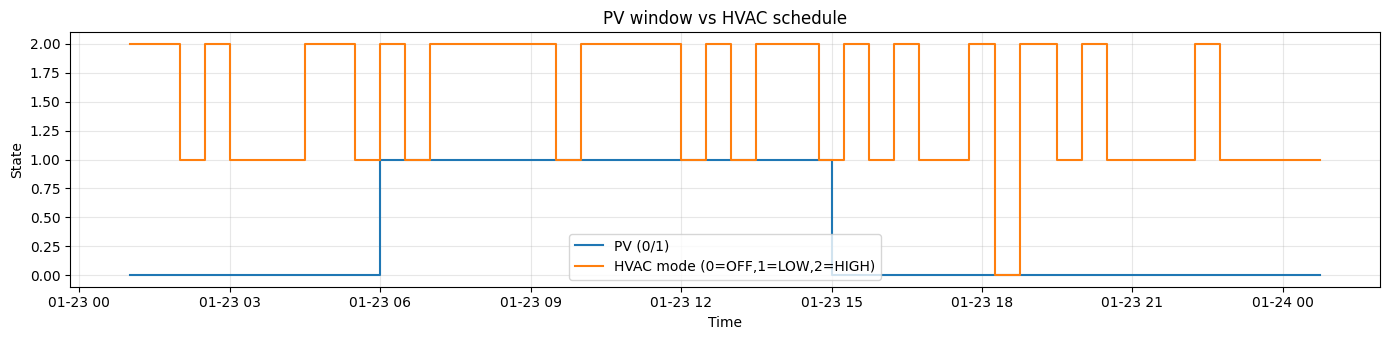

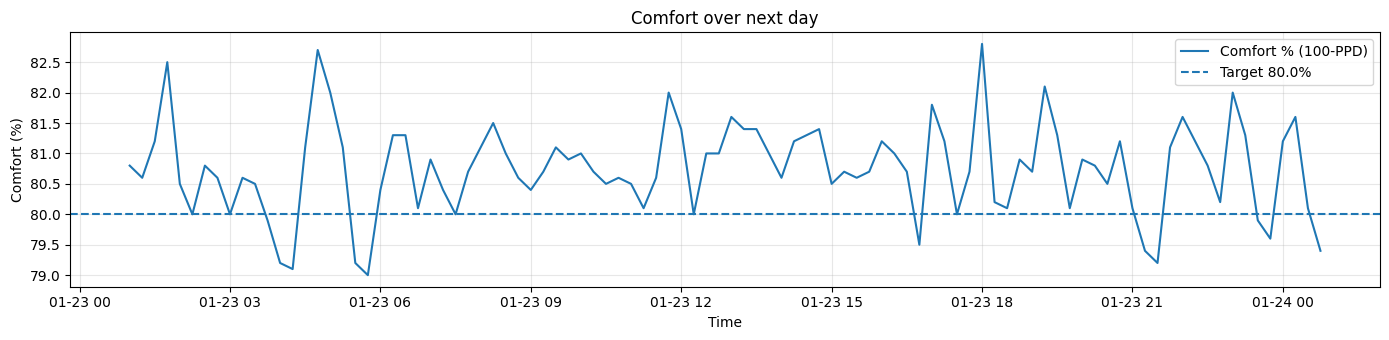

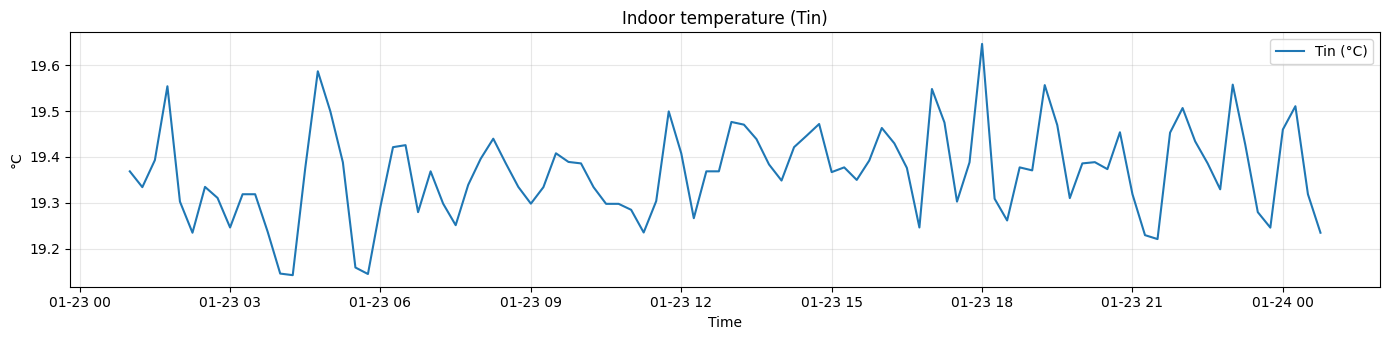

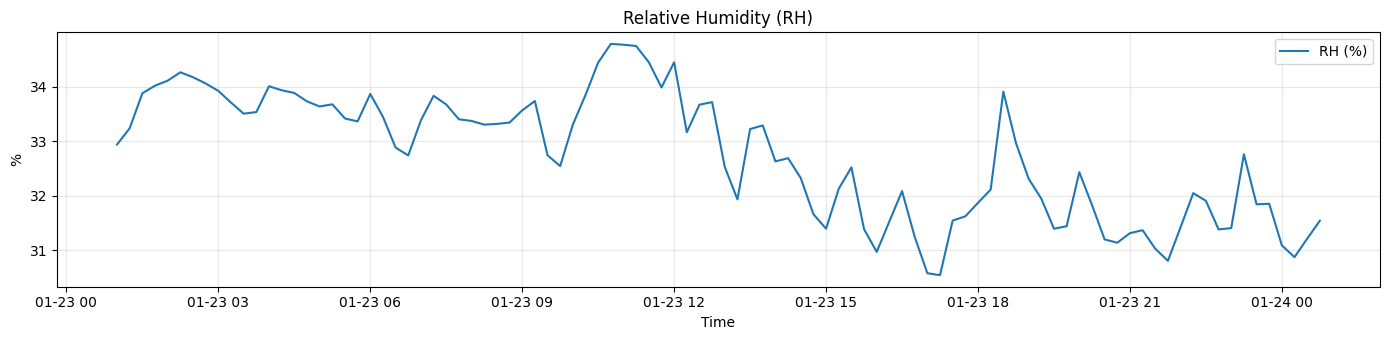

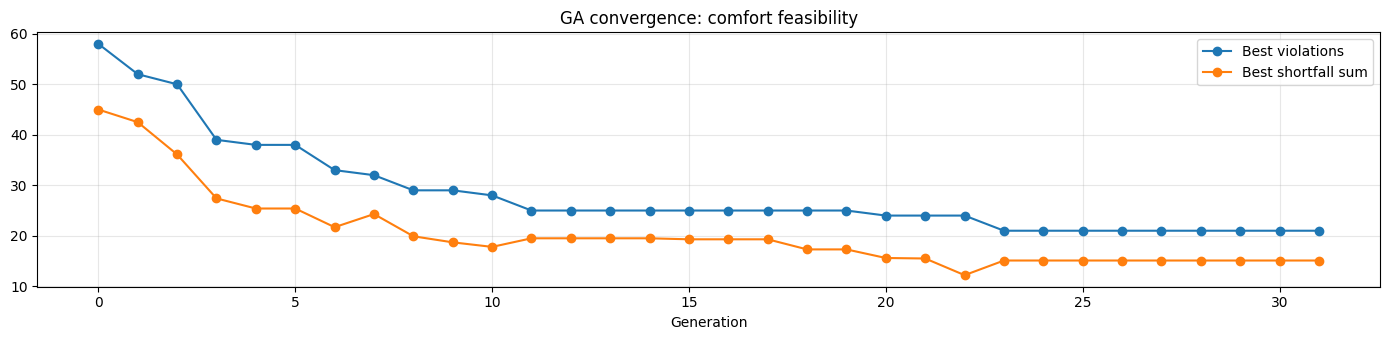

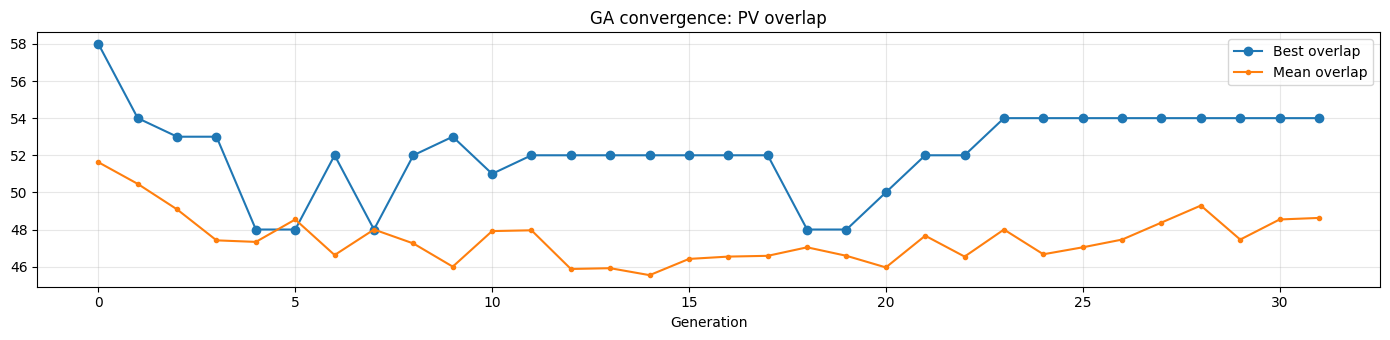

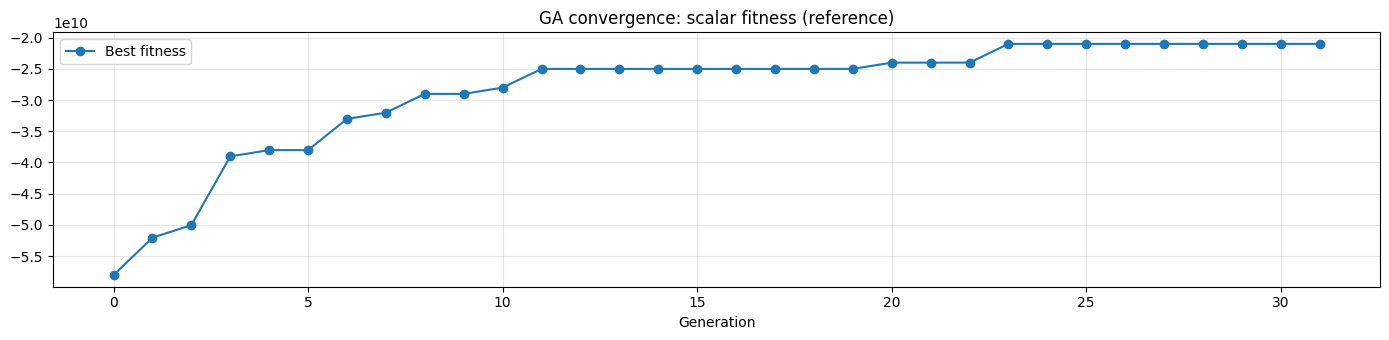

In [11]:
# ===========================
# Heat-pump next-day optimizer (fast GA + plots)
# Uses your step predictor + comfort function
# ===========================

import random
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Hvac_predict_script import predict_next_step

def calculate_overall_comfort(list_tin, list_rh):
    ppd_values = []
    for tin, rh in zip(list_tin, list_rh):
        comfort = pmv_ppd_iso(
            tdb=tin,
            tr=tin,     
            vr=0.1,     
            rh=rh,
            met=1.1,    
            clo=1.0     
        )
        if comfort['ppd'] is None:
            # print(tin)
            ppd_values.append(75)  
        else:
            ppd_values.append(comfort['ppd'])  
    return ppd_values  
# ---------------------------
# 0) CONFIG
# ---------------------------
@dataclass
class OptConfig:
    # horizon
    N: int = 96

    # GA knobs (fast defaults ~15min target depending on model speed)
    pop_size: int = 24
    generations: int = 36
    patience: int = 8
    crossover_p: float = 0.9
    mutation_p: float = 0.08
    tournament_k: int = 3
    seed: int = 42

    # objective + constraints
    comfort_target: float = 80.0
    weight_switching: float = 0.4  # soft anti-chatter
    low_weight: float = 1.0        # PV overlap weight for LOW
    high_weight: float = 2.0       # PV overlap weight for HIGH
    min_dwell: int = 2             # steps to keep same mode
    pv_threshold_kw: float = 0.5   # treat pv_forecast 1s as PV-available

    # feasible-first logic
    feasible_first: bool = True
    allow_repair_in_GA: bool = False  # keep False for runtime; use post_repair after GA
    high_only_during_pv: bool = False
    max_high_steps: Optional[int] = None


# ---------------------------
# 1) UTILITIES
# ---------------------------
def repair_min_dwell(schedule: np.ndarray, min_dwell: int) -> np.ndarray:
    if min_dwell <= 1:
        return schedule
    fixed = schedule.copy()
    run_val = fixed[0]
    run_len = 1
    for i in range(1, len(fixed)):
        if fixed[i] != run_val and run_len < min_dwell:
            fixed[i] = run_val
            run_len += 1
        elif fixed[i] == run_val:
            run_len += 1
        else:
            run_val = fixed[i]
            run_len = 1
    return fixed


def crossover(a: np.ndarray, b: np.ndarray, pc: float) -> Tuple[np.ndarray, np.ndarray]:
    if random.random() > pc or len(a) < 3:
        return a.copy(), b.copy()
    n = len(a)
    cut = random.randint(1, n - 2)
    return np.concatenate([a[:cut], b[cut:]]), np.concatenate([b[:cut], a[cut:]])


def mutate(child: np.ndarray, pm: float) -> np.ndarray:
    for i in range(len(child)):
        if random.random() < pm:
            old = int(child[i])
            choices = [0, 1, 2]
            choices.remove(old)
            child[i] = random.choice(choices)
    return child


def tournament_select_ranked(pop_fits, k):
    sel = random.sample(pop_fits, k)
    sel.sort(key=lambda x: x[1][1]["rank"])  # lower is better
    return sel[0][0]


# ---------------------------
# 2) ADAPTERS to YOUR code
#    (expects your predict_next_step and calculate_overall_comfort)
# ---------------------------
# FAST state (for GA)
def make_initial_state_fast(df_test, start_idx, lstm_model, rf_model, tin_scaler, rh_model, rh_scaler) -> Dict:
    return {
        "df_test": df_test,
        "start_idx": int(start_idx),
        "current_step": -1,
        "schedule": [],        # kept only because your predict_next_step needs it
        "Tin_last": None,
        "RH_last": None,
        "lstm_model": lstm_model,
        "rf_model": rf_model,
        "tin_scaler": tin_scaler,
        "rh_model": rh_model,
        "rh_scaler": rh_scaler,
    }


def predict_step_fast(action: int, state: Dict) -> Dict:
    # NOTE: relies on your global functions:
    #   predict_next_step(df_test, current_idx, schedule, lstm_model, rf_model, tin_scaler, rh_model, rh_scaler)
    #   calculate_overall_comfort([Tin_next], [RH_next]) -> list-like, use [0]
    state["schedule"].append(int(action))
    state["current_step"] += 1

    Tin_next, RH_next = predict_next_step(
        df_test=state["df_test"],
        current_idx=state["start_idx"] + state["current_step"],
        schedule=state["schedule"],
        lstm_model=state["lstm_model"],
        rf_model=state["rf_model"],
        tin_scaler=state["tin_scaler"],
        rh_model=state["rh_model"],
        rh_scaler=state["rh_scaler"],
    )
    state["Tin_last"] = float(Tin_next)
    state["RH_last"] = float(RH_next)
    state["Comfort_pct"] = 100.0 - float(calculate_overall_comfort([Tin_next], [RH_next])[0])
    return state


# FULL state (for rollout & plotting)
def make_initial_state_full(df_test, start_idx, lstm_model, rf_model, tin_scaler, rh_model, rh_scaler) -> Dict:
    return {
        "df_test": df_test,
        "start_idx": int(start_idx),
        "current_step": -1,
        "schedule": [],
        "Tin": [],
        "RH": [],
        "lstm_model": lstm_model,
        "rf_model": rf_model,
        "tin_scaler": tin_scaler,
        "rh_model": rh_model,
        "rh_scaler": rh_scaler,
    }


def predict_step_adapter(action: int, state: Dict) -> Dict:
    state["schedule"].append(int(action))
    state["current_step"] += 1

    Tin_next, RH_next = predict_next_step(
        df_test=state["df_test"],
        current_idx=state["start_idx"] + state["current_step"],
        schedule=state["schedule"],
        lstm_model=state["lstm_model"],
        rf_model=state["rf_model"],
        tin_scaler=state["tin_scaler"],
        rh_model=state["rh_model"],
        rh_scaler=state["rh_scaler"],
    )
    state["Tin"].append(float(Tin_next))
    state["RH"].append(float(RH_next))
    state["Comfort_pct"] = 100.0 - float(calculate_overall_comfort([Tin_next], [RH_next])[0])
    return state


# ---------------------------
# 3) FITNESS (feasible-first + early-exit)
# ---------------------------
class HPFitness:
    def __init__(
        self,
        cfg: OptConfig,
        pv_kw: Sequence[float],
        predict_step_fn,            # use predict_step_fast here
        initial_state: Dict,
    ):
        self.cfg = cfg
        self.pv = np.asarray(pv_kw, dtype=float)
        assert len(self.pv) == cfg.N, "pv_kw must be length 96."
        self.predict_step = predict_step_fn
        self.initial_state = initial_state
        self.cutoff_violations: Optional[int] = None  # set each generation

    def _simulate_stepwise_fast(self, schedule: np.ndarray) -> Dict:
        N = self.cfg.N
        target = self.cfg.comfort_target
        s = dict(self.initial_state)      # fresh copy
        s["schedule"] = []                # fresh list

        violations = 0
        shortfall_sum = 0.0
        pv_mask = (self.pv >= self.cfg.pv_threshold_kw).astype(float)
        overlap_acc = 0.0
        switches = 0
        prev_mode = int(schedule[0])

        for t in range(N):
            s = self.predict_step(int(schedule[t]), s)
            comfort = s["Comfort_pct"]
            short = max(0.0, target - comfort)
            if short > 0:
                violations += 1
                shortfall_sum += short

            # early-exit if dominated by current best in generation
            if (self.cfg.feasible_first and
                self.cutoff_violations is not None and
                violations > self.cutoff_violations):
                return {
                    "violations": violations,
                    "shortfall_sum": shortfall_sum,
                    "overlap_score": overlap_acc,
                    "switches": switches,
                    "schedule": schedule.tolist(),
                }

            # accumulate overlap
            if schedule[t] == 1:
                overlap_acc += pv_mask[t] * self.cfg.low_weight
            elif schedule[t] == 2:
                overlap_acc += pv_mask[t] * self.cfg.high_weight

            # switch count
            if t > 0 and schedule[t] != prev_mode:
                switches += 1
            prev_mode = int(schedule[t])

        return {
            "violations": violations,
            "shortfall_sum": shortfall_sum,
            "overlap_score": overlap_acc,
            "switches": switches,
            "schedule": schedule.tolist(),
        }

    def evaluate(self, schedule: np.ndarray) -> Tuple[float, Dict]:
        # clip & constraints
        schedule = np.clip(schedule, 0, 2)

        if self.cfg.high_only_during_pv:
            mask = (self.pv < self.cfg.pv_threshold_kw) & (schedule == 2)
            schedule[mask] = 1

        if self.cfg.max_high_steps is not None:
            highs = np.where(schedule == 2)[0]
            if len(highs) > self.cfg.max_high_steps:
                to_demote = highs[self.cfg.max_high_steps:]
                schedule[to_demote] = 1

        schedule = repair_min_dwell(schedule, self.cfg.min_dwell)

        stats = self._simulate_stepwise_fast(schedule)

        violations   = int(stats["violations"])
        short_sum    = float(stats["shortfall_sum"])
        overlap      = float(stats["overlap_score"])
        switches     = int(stats["switches"])
        switch_pen   = self.cfg.weight_switching * switches

        # rank tuple (lower is better): violations → shortfall → -overlap → switches
        rank = (violations, round(short_sum * 100), -overlap, switches)

        # scalar fitness (selection uses rank; fitness is for logging)
        if self.cfg.feasible_first and violations > 0:
            fitness = -1e9 * violations - 1e6 * short_sum + overlap - switch_pen
        else:
            fitness = overlap - switch_pen

        details = {
            "rank": rank,
            "overlap_score": overlap,
            "switch_pen": switch_pen,
            "violations": violations,
            "shortfall_sum": short_sum,
            "schedule": stats["schedule"],
        }
        return fitness, details


# ---------------------------
# 4) OPTIMIZER (with history)
# ---------------------------
def optimize_schedule(
    pv_kw: Sequence[float],
    cfg: OptConfig,
    predict_step_fn,      # pass predict_step_fast
    initial_state: Dict,
):
    random.seed(cfg.seed); np.random.seed(cfg.seed)
    fit = HPFitness(cfg, pv_kw, predict_step_fn, initial_state)

    pv_mask = (np.asarray(pv_kw) >= cfg.pv_threshold_kw).astype(int)

    # init population (bias ON during PV)
    pop = []
    for _ in range(cfg.pop_size):
        base = pv_mask.copy()
        for i in range(cfg.N):
            if base[i] == 1:
                base[i] = 1 if random.random() < 0.6 else 2
            else:
                base[i] = 0
        base = repair_min_dwell(base, cfg.min_dwell)
        pop.append(base)

    best = None  # (indiv, (fitness, details))
    no_improve = 0
    history = []

    for gen in range(cfg.generations):
        # quick warm-up to seed cutoff
        warm = []
        for i in range(min(4, len(pop))):
            f, d = fit.evaluate(pop[i])
            warm.append((pop[i], (f, d)))
        warm.sort(key=lambda x: x[1][1]["rank"])
        fit.cutoff_violations = warm[0][1][1]["violations"]

        # evaluate rest with early-exit
        pop_fits = warm.copy()
        for indiv in pop[len(warm):]:
            f, d = fit.evaluate(indiv)
            pop_fits.append((indiv, (f, d)))
            if d["violations"] < fit.cutoff_violations:
                fit.cutoff_violations = d["violations"]

        # best by rank
        gen_best = min(pop_fits, key=lambda x: x[1][1]["rank"])
        if best is None or gen_best[1][1]["rank"] < best[1][1]["rank"]:
            best = gen_best
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= cfg.patience:
            # record history before break
            best_det = gen_best[1][1]
            mean_overlap = float(np.mean([d[1][1]["overlap_score"] for d in pop_fits]))
            mean_viol = float(np.mean([d[1][1]["violations"] for d in pop_fits]))
            history.append({
                "gen": gen,
                "best_fitness": float(gen_best[1][0]),
                "best_violations": int(best_det["violations"]),
                "best_shortfall_sum": float(best_det["shortfall_sum"]),
                "best_overlap": float(best_det["overlap_score"]),
                "best_switches": int(best_det["switch_pen"] / max(1e-9, cfg.weight_switching)),
                "mean_overlap": mean_overlap,
                "mean_violations": mean_viol,
            })
            break

        # history
        best_det = gen_best[1][1]
        mean_overlap = float(np.mean([d[1][1]["overlap_score"] for d in pop_fits]))
        mean_viol = float(np.mean([d[1][1]["violations"] for d in pop_fits]))
        history.append({
            "gen": gen,
            "best_fitness": float(gen_best[1][0]),
            "best_violations": int(best_det["violations"]),
            "best_shortfall_sum": float(best_det["shortfall_sum"]),
            "best_overlap": float(best_det["overlap_score"]),
            "best_switches": int(best_det["switch_pen"] / max(1e-9, cfg.weight_switching)),
            "mean_overlap": mean_overlap,
            "mean_violations": mean_viol,
        })

        # next generation (elitism + tournaments)
        pop_fits.sort(key=lambda x: x[1][1]["rank"])
        new_pop = [pop_fits[0][0].copy(), pop_fits[1][0].copy()]
        while len(new_pop) < cfg.pop_size:
            p1 = tournament_select_ranked(pop_fits, cfg.tournament_k)
            p2 = tournament_select_ranked(pop_fits, cfg.tournament_k)
            c1, c2 = crossover(p1, p2, cfg.crossover_p)
            c1 = repair_min_dwell(mutate(c1, cfg.mutation_p), cfg.min_dwell)
            c2 = repair_min_dwell(mutate(c2, cfg.mutation_p), cfg.min_dwell)
            new_pop.extend([c1, c2])
        pop = new_pop[:cfg.pop_size]

    return {
        "best_fitness": best[1][0],
        "best_details": best[1][1],
        "best_schedule": best[0].tolist(),
        "history": history,
    }


# ---------------------------
# 5) ROLLOUT, POST-REPAIR, PLOTTING
# ---------------------------
def rollout_schedule_stepwise(best_schedule: List[int], initial_state_full: Dict):
    state = dict(initial_state_full)
    Tin_list, RH_list, Comfort_list = [], [], []
    for a in best_schedule:
        state = predict_step_adapter(int(a), state)
        Tin_list.append(state["Tin"][-1])
        RH_list.append(state["RH"][-1])
        Comfort_list.append(state["Comfort_pct"])
    return np.array(Tin_list), np.array(RH_list), np.array(Comfort_list)


def post_repair(schedule: List[int], pv_mask: Sequence[int],
                df_test, start_idx, lstm_model, rf_model, tin_scaler, rh_model, rh_scaler,
                target: float = 80.0, backlook: int = 2, min_dwell: int = 2) -> List[int]:
    # one-pass preheat repair around dips; uses full adapter for accuracy
    init = make_initial_state_full(df_test, start_idx, lstm_model, rf_model, tin_scaler, rh_model, rh_scaler)
    s = dict(init)
    Tin_list, RH_list, Comfort_list = [], [], []
    for a in schedule:
        s = predict_step_adapter(int(a), s)
        Tin_list.append(s["Tin"][-1])
        RH_list.append(s["RH"][-1])
        Comfort_list.append(s["Comfort_pct"])
    Comfort_arr = np.array(Comfort_list)
    dips = np.where(Comfort_arr < target)[0]
    if len(dips) == 0:
        return schedule
    repaired = schedule.copy()
    pv_arr = np.asarray(pv_mask, dtype=int)
    for t in dips:
        for back in range(backlook, -1, -1):  # t-2, t-1, t
            i = t - back
            if i < 0:
                continue
            # if PV available, favor HIGH; otherwise LOW
            repaired[i] = max(repaired[i], 2 if pv_arr[i] == 1 else 1)
    repaired = repair_min_dwell(np.array(repaired), min_dwell=min_dwell).tolist()
    return repaired


def build_time_index(df_test, start_idx, periods=96, freq="15min"):
    ts = None
    if hasattr(df_test, "columns") and "timestamps" in df_test.columns:
        try:
            ts = pd.to_datetime(df_test.iloc[start_idx]["timestamps"])
        except Exception:
            pass
    if ts is None:
        try:
            ts = pd.to_datetime(df_test.index[start_idx])
        except Exception:
            ts = pd.Timestamp.today().normalize()
    return pd.date_range(ts, periods=periods, freq=freq)


def plot_pv_and_schedule(time_idx, pv_mask, schedule):
    plt.figure(figsize=(14, 3.5))
    plt.step(time_idx, np.asarray(pv_mask).astype(int), where="post", label="PV (0/1)")
    plt.step(time_idx, np.asarray(schedule), where="post", label="HVAC mode (0=OFF,1=LOW,2=HIGH)")
    plt.title("PV window vs HVAC schedule")
    plt.ylabel("State")
    plt.xlabel("Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_comfort(time_idx, comfort, target=80.0):
    plt.figure(figsize=(14, 3.5))
    plt.plot(time_idx, comfort, label="Comfort % (100-PPD)")
    plt.axhline(target, linestyle="--", label=f"Target {target}%")
    plt.title("Comfort over next day")
    plt.ylabel("Comfort (%)")
    plt.xlabel("Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_tin(time_idx, Tin):
    plt.figure(figsize=(14, 3.5))
    plt.plot(time_idx, Tin, label="Tin (°C)")
    plt.title("Indoor temperature (Tin)")
    plt.ylabel("°C")
    plt.xlabel("Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_rh(time_idx, RH):
    plt.figure(figsize=(14, 3.5))
    plt.plot(time_idx, RH, label="RH (%)")
    plt.title("Relative Humidity (RH)")
    plt.ylabel("%")
    plt.xlabel("Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_ga_history(history: List[Dict]):
    if not history:
        print("No GA history found.")
        return
    gens = [h["gen"] for h in history]

    plt.figure(figsize=(14, 3.5))
    plt.plot(gens, [h["best_violations"] for h in history], marker="o", label="Best violations")
    plt.plot(gens, [h["best_shortfall_sum"] for h in history], marker="o", label="Best shortfall sum")
    plt.title("GA convergence: comfort feasibility")
    plt.xlabel("Generation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 3.5))
    plt.plot(gens, [h["best_overlap"] for h in history], marker="o", label="Best overlap")
    plt.plot(gens, [h["mean_overlap"] for h in history], marker=".", label="Mean overlap")
    plt.title("GA convergence: PV overlap")
    plt.xlabel("Generation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 3.5))
    plt.plot(gens, [h["best_fitness"] for h in history], marker="o", label="Best fitness")
    plt.title("GA convergence: scalar fitness (reference)")
    plt.xlabel("Generation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------
# 6) EXAMPLE USAGE
# ---------------------------
# FILL ME (use your variables / functions):
# - pv_forecast: list/np.array length 96 with 0/1
# - df_test, start_idx
# - tin_model, rf_model, scaler_tin, rh_model, scaler_rh
# - predict_next_step(...) and calculate_overall_comfort(...)

# Example run (uncomment and fill):
# pv_forecast = your_binary_list_len_96
# df_test = ...
# start_idx = ...
# tin_model = ...
# rf_model = ...
# scaler_tin = ...
# rh_model = ...
# scaler_rh = ...

cfg = OptConfig(
    pop_size=24, generations=36, patience=8,
    min_dwell=2, low_weight=1.0, high_weight=2.0,
    pv_threshold_kw=0.5,
    feasible_first=True, high_only_during_pv=False, max_high_steps=40
)

# # FAST GA evaluation
initial_state_fast = make_initial_state_fast(df_encoded_test, 100, tin_model, rf_model, scaler_tin, rh_model, scaler_rh)
result = optimize_schedule(
    pv_kw=pv_forecast,
    cfg=cfg,
    predict_step_fn=predict_step_fast,
    initial_state=initial_state_fast,
)
best_schedule = result["best_schedule"]
hist = result["history"]
print("=== GA result ===")
print("Best rank (viol, shortfall*100, -overlap, switches):", result["best_details"]["rank"])
print("Overlap:", result["best_details"]["overlap_score"], "Switch_pen:", result["best_details"]["switch_pen"])

# # Optional: one cheap repair pass AFTER GA, then re-rollout
best_schedule = post_repair(
    schedule=best_schedule,
    pv_mask=pv_forecast,
    df_test=df_encoded_test, start_idx=100,
    lstm_model=tin_model, rf_model=rf_model, tin_scaler=scaler_tin, rh_model=rh_model, rh_scaler=scaler_rh,
    target=cfg.comfort_target, backlook=2, min_dwell=cfg.min_dwell
)

# # Rollout for plots with FULL adapter
initial_state_full = make_initial_state_full(df_encoded_test, 100, tin_model, rf_model, scaler_tin, rh_model, scaler_rh)
Tin_arr, RH_arr, Comfort_arr = rollout_schedule_stepwise(best_schedule, initial_state_full)
time_idx = build_time_index(df_encoded_test, 100)

# # Plots
plot_pv_and_schedule(time_idx, pv_forecast, best_schedule)
plot_comfort(time_idx, Comfort_arr, target=cfg.comfort_target)
plot_tin(time_idx, Tin_arr)
plot_rh(time_idx, RH_arr)
plot_ga_history(hist)


Ground truth hvac_mode counts (steps / minutes):
{0: (57, 855), 1: (15, 225), 2: (24, 360)}
Optimized hvac_mode counts (steps / minutes):
{0: (2, 30), 1: (44, 660), 2: (50, 750)}


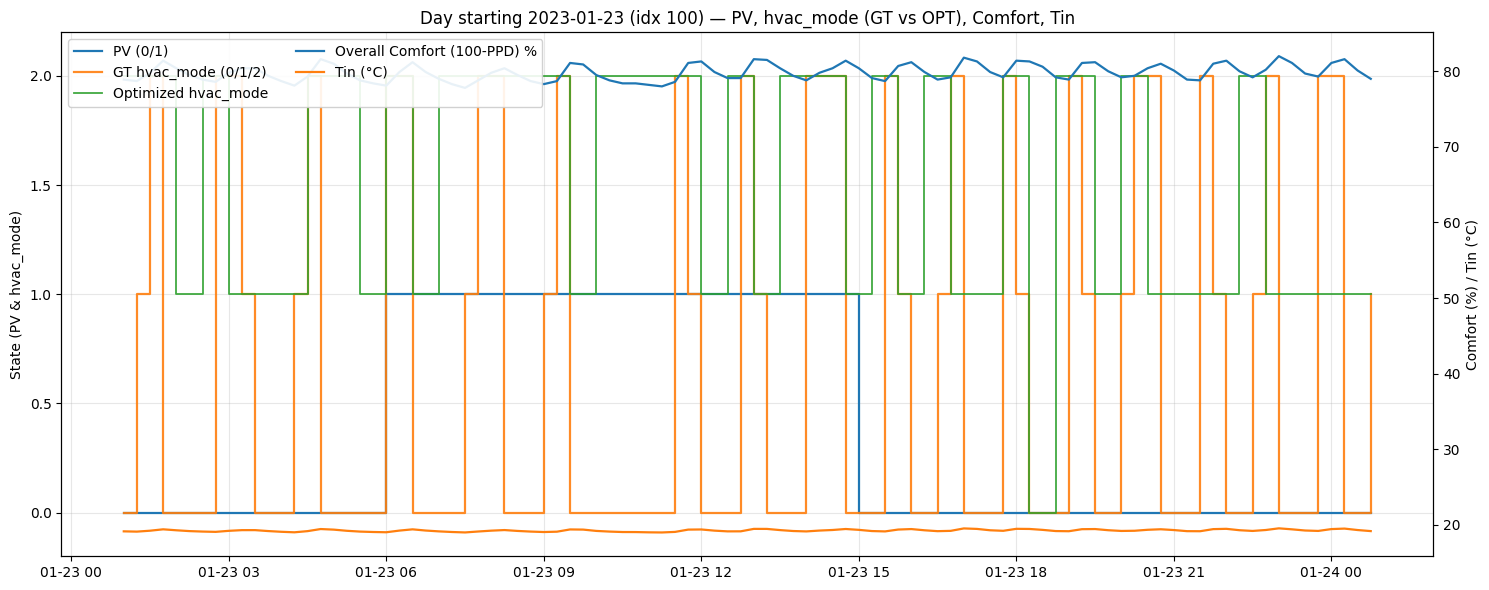


=== PV overlap comparison (per 24h day) ===
                  Ground truth  Optimized
LOW@PV_steps          4.000000        9.0
LOW@PV_min           60.000000      135.0
HIGH@PV_steps        10.000000       27.0
HIGH@PV_min         150.000000      405.0
ON@PV_steps          14.000000       36.0
ON@PV_min           210.000000      540.0
OFF@PV_steps         22.000000        0.0
OFF@PV_min          330.000000        0.0
PV_window_steps      36.000000       36.0
PV_window_min       540.000000      540.0
PV_utilization_%     38.888889      100.0
High_share@PV_%      71.428571       75.0


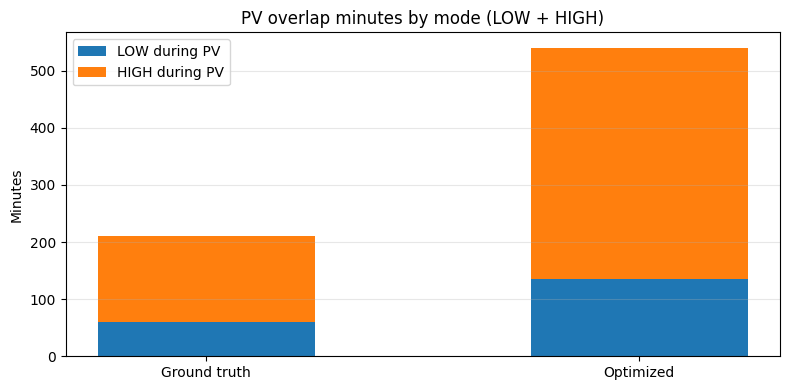

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# --- params
start_idx = 100    # as you said
horizon = 96       # 96 x 15min = 24h

# --- slice the day
df_day = df_encoded_test.iloc[start_idx:start_idx + horizon].copy()
assert len(df_day) == horizon, f"Day slice length is {len(df_day)} not {horizon}."

# time axis
if "timestamps" in getattr(df_day, "columns", []):
    time_idx = pd.to_datetime(df_day["timestamps"])
else:
    time_idx = pd.to_datetime(df_day.index)

# pick comfort column name (you said 'overall_comfort' exists)
comfort_col = "overall_comfort" if "overall_comfort" in df_day.columns else (
    "Overall_Comfort" if "Overall_Comfort" in df_day.columns else None
)
if comfort_col is None:
    raise KeyError("Could not find 'overall_comfort' or 'Overall_Comfort' column in df_encoded_test.")

# arrays
pv_day   = np.asarray(pv_forecast, dtype=int)
sched_gt = df_day["hvac_mode"].astype(int).to_numpy()
Tin_day  = df_day["Tin"].astype(float).to_numpy()
Comfort_day = df_day[comfort_col].astype(float).to_numpy()

# sanity
assert pv_day.shape == (horizon,), "pv_forecast must be length 96."
assert len(best_schedule) == horizon, "best_schedule must be length 96."

sched_opt = np.asarray(best_schedule, dtype=int)

# --- counts
gt_counts = pd.Series(sched_gt).value_counts().reindex([0,1,2], fill_value=0)
opt_counts = pd.Series(sched_opt).value_counts().reindex([0,1,2], fill_value=0)

print("Ground truth hvac_mode counts (steps / minutes):")
print({k: (int(v), int(v)*15) for k, v in gt_counts.items()})
print("Optimized hvac_mode counts (steps / minutes):")
print({k: (int(v), int(v)*15) for k, v in opt_counts.items()})

# --- single figure with twin y-axes
fig, ax1 = plt.subplots(figsize=(15, 6))

# left axis: PV, GT schedule, OPT schedule (step plots)
ax1.step(time_idx, pv_day, where="post", label="PV (0/1)", linewidth=1.6)
ax1.step(time_idx, sched_gt, where="post", label="GT hvac_mode (0/1/2)", linewidth=1.6, alpha=0.9)
ax1.step(time_idx, sched_opt, where="post", label="Optimized hvac_mode", linewidth=1.3, alpha=0.9)
ax1.set_ylim(-0.2, 2.2)
ax1.set_ylabel("State (PV & hvac_mode)")
ax1.grid(True, alpha=0.3)

# right axis: Comfort (%) and Tin (°C)
ax2 = ax1.twinx()
ax2.plot(time_idx, Comfort_day, label="Overall Comfort (100-PPD) %", linewidth=1.6)
ax2.plot(time_idx, Tin_day, label="Tin (°C)", linewidth=1.6)
ax2.set_ylabel("Comfort (%) / Tin (°C)")

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left", ncol=2, framealpha=0.9)

# title with day info
title_ts = pd.to_datetime(time_idx[0]).strftime("%Y-%m-%d")
ax1.set_title(f"Day starting {title_ts} (idx {start_idx}) — PV, hvac_mode (GT vs OPT), Comfort, Tin")

plt.tight_layout()
plt.show()

def pv_overlap_stats(schedule, pv_mask):
    schedule = np.asarray(schedule, dtype=int)
    pv_mask  = np.asarray(pv_mask, dtype=int)
    low_pv   = int(np.sum((schedule == 1) & (pv_mask == 1)))
    high_pv  = int(np.sum((schedule == 2) & (pv_mask == 1)))
    on_pv    = low_pv + high_pv
    pv_steps = int(np.sum(pv_mask == 1))
    off_pv   = pv_steps - on_pv
    return {
        "LOW@PV_steps": low_pv,
        "LOW@PV_min": low_pv * 15,
        "HIGH@PV_steps": high_pv,
        "HIGH@PV_min": high_pv * 15,
        "ON@PV_steps": on_pv,
        "ON@PV_min": on_pv * 15,
        "OFF@PV_steps": off_pv,
        "OFF@PV_min": off_pv * 15,
        "PV_window_steps": pv_steps,
        "PV_window_min": pv_steps * 15,
        "PV_utilization_%": (on_pv / pv_steps * 100) if pv_steps > 0 else np.nan,
        "High_share@PV_%": (high_pv / on_pv * 100) if on_pv > 0 else np.nan,
    }

gt_stats  = pv_overlap_stats(sched_gt, pv_day)
opt_stats = pv_overlap_stats(sched_opt, pv_day)

stats_df = pd.DataFrame([gt_stats, opt_stats], index=["Ground truth", "Optimized"]).T
print("\n=== PV overlap comparison (per 24h day) ===")
print(stats_df)

labels = ["Ground truth", "Optimized"]
low_minutes  = [gt_stats["LOW@PV_min"],  opt_stats["LOW@PV_min"]]
high_minutes = [gt_stats["HIGH@PV_min"], opt_stats["HIGH@PV_min"]]

x = np.arange(len(labels))
width = 0.5
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, low_minutes,  width, label="LOW during PV")
ax.bar(x, high_minutes, width, bottom=low_minutes, label="HIGH during PV")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Minutes")
ax.set_title("PV overlap minutes by mode (LOW + HIGH)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import os

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('with_comfort.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)

In [32]:
from typing import Tuple

def make_splits_by_is_test_or_date(
    df: pd.DataFrame,
    val_start_str: str = "2023-01-22",
    val_days: int = 14,
    test_days: int = 14,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
   
    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        if "timestamps" in df.columns:
            df = df.copy()
            df["timestamps"] = pd.to_datetime(df["timestamps"])
            df = df.set_index("timestamps")
        else:
            raise ValueError("DataFrame must have a DateTimeIndex or a 'timestamps' column.")

    # Define windows
    val_start = pd.Timestamp(val_start_str)
    val_end   = val_start + pd.Timedelta(days=val_days)
    test_start = val_end
    test_end   = test_start + pd.Timedelta(days=test_days)

    # Build masks (inclusive start, exclusive end)
    idx = np.arange(len(df))
    ts = df.index

    val_mask  = (ts >= val_start) & (ts < val_end)
    test_mask = (ts >= test_start) & (ts < test_end)

    # Ensure they are disjoint
    overlap = val_mask & test_mask
    if overlap.any():
        raise RuntimeError("Validation and test windows overlap; check the inputs.")

    train_mask = ~(val_mask | test_mask)

    train_idx = idx[train_mask]
    val_idx   = idx[val_mask]
    test_idx  = idx[test_mask]

    return train_idx, val_idx, test_idx

df = dfs[0]
train_idx, val_idx, test_idx = make_splits_by_is_test_or_date(df, val_start_str="2023-01-22", val_days=14, test_days=14)
df['RH_lag1'] = df['RH'].shift(1).fillna(0)
df['RH_lag2'] = df['RH'].shift(2).fillna(0)
df['RH_lag3'] = df['RH'].shift(3).fillna(0)
df['RH_lag4'] = df['RH'].shift(4).fillna(0)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)


In [33]:
pv_data = pd.read_csv('datasets/pv_data/shifted_pv_data.csv')

start_time = df.index[test_idx]
end_time = start_time + pd.Timedelta(minutes=15 * 95)
pv_data['timestamps'] = pd.to_datetime(pv_data["timestamps"])  # just in case
pv_window = pv_data[
    (pv_data["timestamps"] >= start_time[0]) &
    (pv_data["timestamps"] <= end_time[0])
].copy()


pv_forecast = (pv_window["total_energy"] > 0.05).astype(int).tolist()
time_steps = 96
print(len(pv_forecast) == time_steps)

True


In [34]:
import torch
import torch.nn as nn
import joblib
from collections import deque

# Your class (as given)
class CNNLSTMWithFuture(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, cnn_out_channels=32, kernel_size=3):
        super().__init__()
        self.conv1d = nn.Conv1d(in_channels=input_size, out_channels=cnn_out_channels,
                                kernel_size=kernel_size, padding=kernel_size // 2)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(input_size=cnn_out_channels, hidden_size=hidden_size,
                            num_layers=num_layers, dropout=0.15, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x_seq):
        x_seq = x_seq.permute(0, 2, 1)     # (B, C, L)
        x_seq = self.relu(self.conv1d(x_seq))
        x_seq = x_seq.permute(0, 2, 1)     # (B, L, C)
        _, (hn, _) = self.lstm(x_seq)
        return self.fc(hn[-1]).squeeze(-1)  # (B,)

# paths (adjust df_x index if needed)
TIN_RF_PATH = "models/df_0/best_model_rf.pkl"
RH_MODEL_PATH = "models/df_0/best_rh.pt"
RH_SCALER_PATH = "models/scalers/df_0/scaler_rh.pkl"

# columns
rh_input_cols = [
    'RH', 'RH_lag1', 'RH_lag2', 'RH_lag3',
    'Tout', 'hvac_mode', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]
rh_scale_cols = ['Tout', 'hvac_mode']  # only these pass the scaler

# lazy singletons
_TIN_RF = None
_RH_NET = None
_RH_SCALER = None

def load_tin_rf(path=TIN_RF_PATH):
    global _TIN_RF
    if _TIN_RF is None:
        _TIN_RF = joblib.load(path)
    return _TIN_RF

def load_rh_model_and_scaler(model_path=RH_MODEL_PATH, scaler_path=RH_SCALER_PATH, input_size=10, device="cpu"):
    """
    Tries to load either a full model or a state_dict. Returns (net.eval(), scaler, device).
    """
    global _RH_NET, _RH_SCALER
    if _RH_NET is None:
        net = CNNLSTMWithFuture(input_size=input_size)
        blob = torch.load(model_path, map_location=device)
        if isinstance(blob, dict) and all(k in blob for k in ("state_dict", "input_size")):
            # custom checkpoint format
            if blob.get("input_size", input_size) != input_size:
                raise ValueError(f"Checkpoint input_size={blob.get('input_size')} != expected {input_size}")
            net.load_state_dict(blob["state_dict"])
        elif isinstance(blob, dict) and any(k.startswith("conv1d.") or k.startswith("lstm.") for k in blob.keys()):
            # pure state_dict
            net.load_state_dict(blob)
        else:
            # saved full model
            net = blob
        net.to(device).eval()
        _RH_NET = net

    if _RH_SCALER is None:
        _RH_SCALER = joblib.load(scaler_path)
    return _RH_NET, _RH_SCALER, device

[rollout] start_idx=16746, df_len=24890, hist needed=24, avail_before=16746, H=96


c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_11424\3331230840.py:316: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 2.32471488 -0.59072544  2.32471488  2.32471488 -0.59072544  2.32471488
  2.32471488  0.86699472  2.32471488  0.86699472  0.86699472  2.32471488
  2.32471488  2.32471488  2.32471488  0.86699472  2.32471488  0.86699472
  2.32471488  2.32471488 -0.59072544  2.32471488  2.32471488  0.86699472]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, rh_scale_cols] = rh_scaler.transform(vals)  # only scale these two
c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Standa

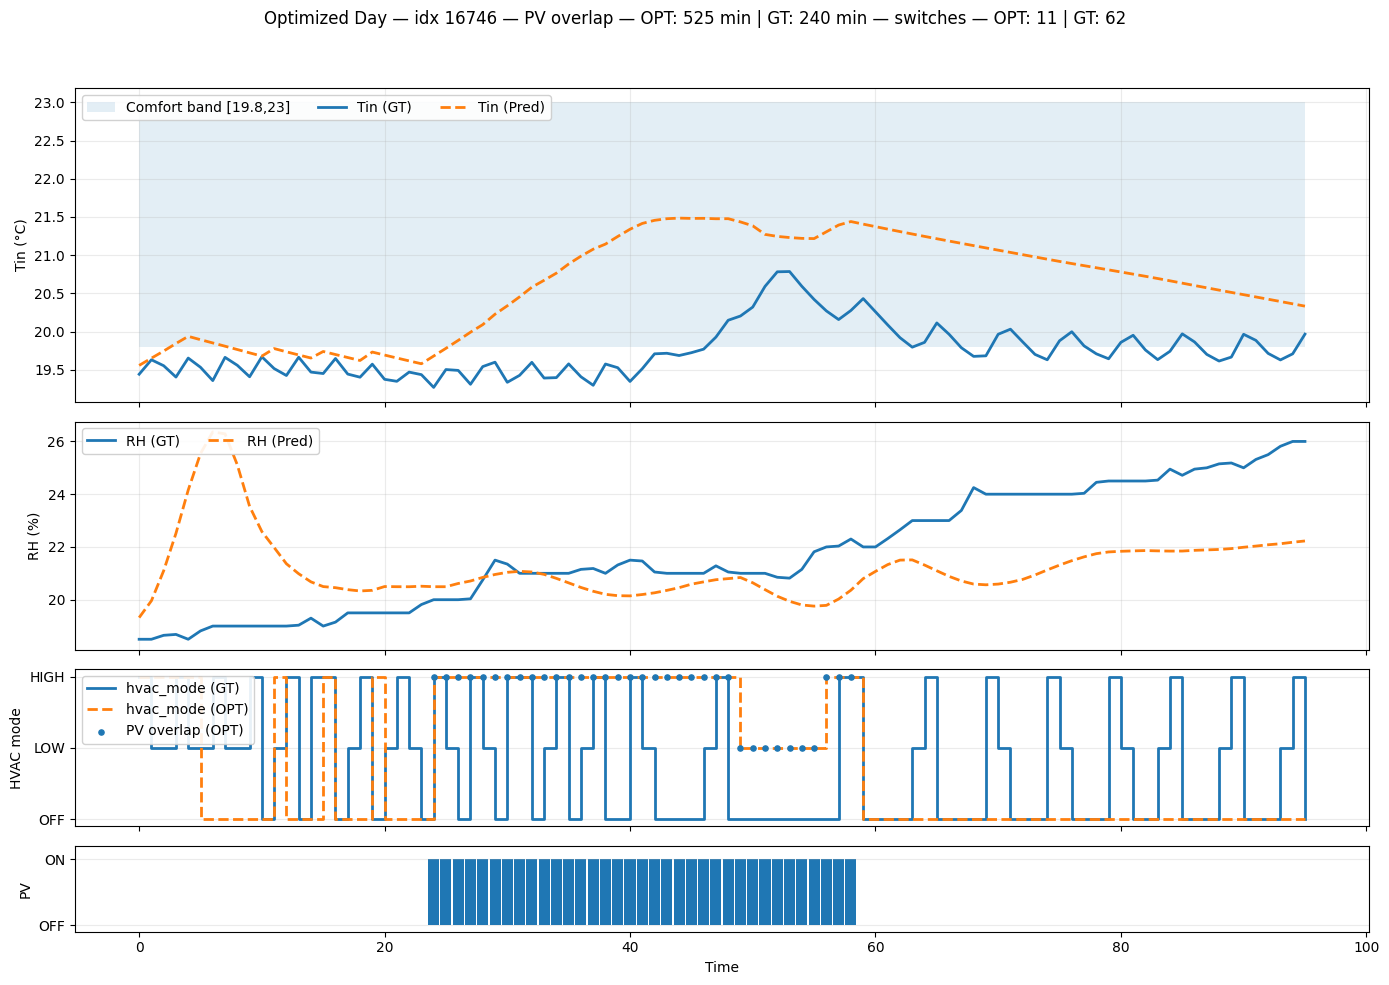

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, Tuple, Optional, Dict

# ---------- Pyomo ----------
from pyomo.environ import (
    ConcreteModel, Var, Objective, Constraint, RangeSet, NonNegativeReals, Binary,
    Reals, Param, value, SolverFactory, minimize
)
import joblib
# ------------------------- RC/ARX surrogate -------------------------

# def load_rf_model(path="models/df_0/best_model_rf.pkl"):
#     model = joblib.load(path)
#     return model

# RF_MODEL = load_rf_model()  # load once


@dataclass
class RCParams:
    a: float
    b_tout: float
    c_low: float
    c_high: float
    d: float

def fit_rc_from_df(df: pd.DataFrame) -> RCParams:
    if not {'Tin','Tout','hvac_mode'}.issubset(df.columns):
        raise ValueError("df must contain Tin, Tout, hvac_mode")

    df = df.copy().reset_index(drop=True)
    u_low  = (df['hvac_mode'] == 1).astype(float).values[:-1]
    u_high = (df['hvac_mode'] == 2).astype(float).values[:-1]
    Tin_t  = df['Tin'].values[:-1]
    Tout_t = df['Tout'].values[:-1]
    Tin_next = df['Tin'].values[1:]

    X = np.column_stack([Tin_t, Tout_t, u_low, u_high, np.ones_like(Tin_t)])
    theta, *_ = np.linalg.lstsq(X, Tin_next, rcond=None)
    a, b_tout, c_low, c_high, d = theta.tolist()
    a = float(np.clip(a, 0.7, 0.999))  # stabilize a bit
    return RCParams(a=float(a), b_tout=float(b_tout), c_low=float(c_low), c_high=float(c_high), d=float(d))

# ------------------------- MILP optimizer -------------------------

@dataclass
class OptimizeConfig:
    horizon: int = 96
    Tmin: float = 20.0
    Tmax: float = 24.5
    w_low: float = 1.0
    w_high: float = 2.0
    lambda_noPV: float = 0.15
    lambda_slack: float = 50.0
    lambda_switch: float = 0.05
    safety_buffer: float = 0.0
    solver: str = "highs"     # "cbc", "highs", "gurobi"...
    time_limit_sec: Optional[int] = 60

def optimize_schedule_with_rc(
    rc: RCParams,
    Tin0: float,
    Tout_forecast: np.ndarray,
    pv_forecast: np.ndarray,
    cfg: OptimizeConfig
) -> Dict[str, np.ndarray]:
    H = cfg.horizon
    assert len(Tout_forecast) == H and len(pv_forecast) == H

    m = ConcreteModel()
    m.T = RangeSet(0, H)     # states Tin[0..H]
    m.K = RangeSet(1, H)     # decisions 1..H

    # Params
    m.a = Param(initialize=rc.a)
    m.b_tout = Param(initialize=rc.b_tout)
    m.c_low = Param(initialize=rc.c_low)
    m.c_high = Param(initialize=rc.c_high)
    m.d = Param(initialize=rc.d)
    m.Tout = Param(m.K, initialize={t: float(Tout_forecast[t-1]) for t in m.K})
    m.PV   = Param(m.K, initialize={t: float(pv_forecast[t-1]) for t in m.K})

    # Vars
    m.u_low  = Var(m.K, domain=Binary)
    m.u_high = Var(m.K, domain=Binary)
    m.Tin    = Var(m.T, domain=Reals)
    m.s      = Var(m.K, domain=NonNegativeReals)  # comfort slack
    m.dlow   = Var(RangeSet(2, H), domain=NonNegativeReals)
    m.dhigh  = Var(RangeSet(2, H), domain=NonNegativeReals)

    # Initial condition
    m.init_con = Constraint(expr=m.Tin[0] == Tin0)

    # Dynamics: Tin_{t+1} = a*Tin_t + b*Tout_t + c_low*u_low + c_high*u_high + d
    def dyn_con(m, t):
        return m.Tin[t] * m.a + m.b_tout*m.Tout[t+1] + m.c_low*m.u_low[t+1] + m.c_high*m.u_high[t+1] + m.d == m.Tin[t+1]
    m.dyn_con = Constraint(RangeSet(0, H-1), rule=dyn_con)

    # Mutually exclusive modes
    m.excl = Constraint(m.K, rule=lambda m,t: m.u_low[t] + m.u_high[t] <= 1)

    # Comfort constraints (per step) with safety buffer
    Tmin_eff = cfg.Tmin + cfg.safety_buffer
    Tmax_eff = cfg.Tmax - cfg.safety_buffer
    m.comfort_lo = Constraint(m.K, rule=lambda m,t: m.Tin[t] >= Tmin_eff - m.s[t])
    m.comfort_hi = Constraint(m.K, rule=lambda m,t: m.Tin[t] <= Tmax_eff + m.s[t])

    # Switching penalty (~|u_t - u_{t-1}|)
    m.switch_low_pos  = Constraint(RangeSet(2,H), rule=lambda m,t: m.dlow[t]  >= m.u_low[t]  - m.u_low[t-1])
    m.switch_low_neg  = Constraint(RangeSet(2,H), rule=lambda m,t: m.dlow[t]  >= m.u_low[t-1]  - m.u_low[t])
    m.switch_high_pos = Constraint(RangeSet(2,H), rule=lambda m,t: m.dhigh[t] >= m.u_high[t] - m.u_high[t-1])
    m.switch_high_neg = Constraint(RangeSet(2,H), rule=lambda m,t: m.dhigh[t] >= m.u_high[t-1] - m.u_high[t])

    # Objective = penalties - PV reward  (we minimize)
    def obj_rule(m):
        pv_reward  = sum(m.PV[t]*(cfg.w_low*m.u_low[t] + cfg.w_high*m.u_high[t]) for t in m.K)
        nopv_pen   = cfg.lambda_noPV * sum((1.0 - m.PV[t])*(m.u_low[t] + m.u_high[t]) for t in m.K)
        slack_pen  = cfg.lambda_slack * sum(m.s[t] for t in m.K)
        switch_pen = cfg.lambda_switch * (sum(m.dlow[t] for t in range(2,H+1)) + sum(m.dhigh[t] for t in range(2,H+1)))
        return (nopv_pen + slack_pen + switch_pen) - pv_reward
    m.obj = Objective(rule=obj_rule, sense=minimize)

    opt = SolverFactory(cfg.solver)
    if cfg.time_limit_sec and cfg.solver == "cbc":
        opt.options["sec"] = cfg.time_limit_sec
    if cfg.time_limit_sec and cfg.solver == "highs":
        opt.options["time_limit"] = cfg.time_limit_sec

    res = opt.solve(m, tee=False)

    u_low  = np.array([value(m.u_low[t]) for t in range(1, H+1)], dtype=float)
    u_high = np.array([value(m.u_high[t]) for t in range(1, H+1)], dtype=float)
    Tin_rc = np.array([value(m.Tin[t]) for t in range(0, H+1)], dtype=float)

    hvac_mode = np.zeros(H, dtype=int)
    hvac_mode[u_low  > 0.5] = 1
    hvac_mode[u_high > 0.5] = 2

    return {"hvac_mode": hvac_mode, "Tin_rc": Tin_rc, "u_low": u_low, "u_high": u_high}

# ------------------------- Outer loop (optimize → validate → retry) -------------------------

def optimize_validate_loop(
    df: pd.DataFrame,
    pv_forecast: pd.Series,
    start_idx: int,
    simulate_fn: Callable[[float, np.ndarray, np.ndarray], Tuple[np.ndarray, np.ndarray]],
    Tmin: float = 20.0,
    Tmax: float = 24.5,
    comfort_check: Optional[Callable[[np.ndarray, np.ndarray], bool]] = None,
    max_retries: int = 3
) -> Dict[str, np.ndarray]:
    H = 96
    rc = fit_rc_from_df(df)

    Tout_96 = df['Tout'].iloc[start_idx:start_idx+H].to_numpy()
    Tin0    = float(df['Tin'].iloc[start_idx])
    pv_96   = np.asarray(pv_forecast).astype(float).reshape(-1)
    if len(pv_96) != H:
        raise ValueError("pv_forecast must have length 96")

    def default_comfort_check(Tin_pred: np.ndarray, RH_pred: np.ndarray) -> bool:
        return (Tin_pred >= Tmin).all() and (Tin_pred <= Tmax).all()

    check = comfort_check or default_comfort_check

    cfg = OptimizeConfig(
        horizon=H, Tmin=Tmin, Tmax=Tmax,
        w_low=1.0, w_high=2.2,
        lambda_noPV=0.12, lambda_slack=40.0, lambda_switch=0.05,
        safety_buffer=0.0, solver="cbc", time_limit_sec=60
    )

    last_sol = None
    for attempt in range(max_retries+1):
        sol = optimize_schedule_with_rc(rc, Tin0, Tout_96, pv_96, cfg)
        hvac_mode_96 = sol["hvac_mode"]

        Tin_pred, RH_pred = simulate_fn(Tin0, Tout_96, hvac_mode_96)
        if check(Tin_pred, RH_pred):
            pv_overlap_steps = int(np.sum((pv_96 > 0.5) & (hvac_mode_96 > 0)))
            return {
                "hvac_mode": hvac_mode_96,
                "Tin_pred": Tin_pred,
                "RH_pred": RH_pred,
                "pv_overlap_minutes": int(pv_overlap_steps * 15),
                "attempts": attempt + 1,
                "rc_params": rc.__dict__
            }

        # tighten and retry
        cfg.safety_buffer = min(cfg.safety_buffer + 0.2, 1.0)
        cfg.lambda_slack *= 1.8
        last_sol = sol

    # return last attempt if still not OK
    if last_sol is None:
        raise RuntimeError("No solution produced.")
    Tin_pred, RH_pred = simulate_fn(Tin0, Tout_96, last_sol["hvac_mode"])
    pv_overlap_steps = int(np.sum((pv_96 > 0.5) & (last_sol["hvac_mode"] > 0)))
    return {
        "hvac_mode": last_sol["hvac_mode"],
        "Tin_pred": Tin_pred,
        "RH_pred": RH_pred,
        "pv_overlap_minutes": int(pv_overlap_steps * 15),
        "attempts": max_retries + 1,
        "rc_params": rc.__dict__,
        "note": "Comfort not fully satisfied after retries; consider adjusting bounds/model."
    }

# ------------------------- Adapter: plug in YOUR simulator -------------------------

def your_simulate_fn(Tin0: float, Tout_96: np.ndarray, hvac_mode_96: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Replace this body to call YOUR predictor.
    Must return (Tin_pred[96], RH_pred[96]).

    Example if your function is: forecast_fn(df, start_idx, hvac_future):
        - hvac_future must be length-96 list/array with values {0,1,2}
        - Convert Tin0/Tout_96 if your function needs full df slice (use start_idx from outside)
    """
    raise NotImplementedError("Plug your Tin/RH predictor here.")

# ------------------------- Plotting -------------------------

def _safe_rh_history_window(df, start_idx, cols, window=24):
    """
    Returns exactly `window` rows ending at start_idx-1 (positional).
    If fewer rows are available (e.g., after filtering), front-pad using
    the earliest available row so shape is always (window, len(cols)).
    """
    # Take all rows strictly before start_idx
    avail = df.iloc[:start_idx][cols]
    n = len(avail)
    if n >= window:
        hist = avail.iloc[-window:].copy()
    elif n > 0:
        pad_n = window - n
        first_row = avail.iloc[[0]].copy()
        pad_block = pd.concat([first_row] * pad_n, ignore_index=True)
        hist = pd.concat([pad_block, avail.reset_index(drop=True)], ignore_index=True)
    else:
        # Extremely unlikely in your case, but keep it safe
        neutral = pd.DataFrame([{c: 0.0 for c in cols}])
        hist = pd.concat([neutral] * window, ignore_index=True)
    return hist

def _safe_rh_lag_seed(df, start_idx):
    """
    Returns deque([RH_{t-3}, RH_{t-2}, RH_{t-1}], maxlen=3) using positional rows.
    If fewer than 3 exist, left-pad with the earliest available value.
    """
    from collections import deque
    avail = df.iloc[:start_idx]['RH'].astype(float)
    n = len(avail)
    if n >= 3:
        vals = [avail.iloc[-3], avail.iloc[-2], avail.iloc[-1]]
    elif n > 0:
        v0 = float(avail.iloc[0])
        tail = avail.tolist()
        vals = [v0] * (3 - len(tail)) + tail
    else:
        vals = [0.0, 0.0, 0.0]
    return deque(vals, maxlen=3)

@torch.no_grad()
def rollout_tin_rf_rc_and_rh_cnnlstm(
    df: pd.DataFrame,
    start_idx: int,
    Tout_96: np.ndarray,
    hvac_mode_96: np.ndarray,
    rc: RCParams,
    tin_clip: Tuple[float, float] = (10.0, 40.0),
    device: str = "cpu"
):
    """
    Returns Tin_pred[96], RH_pred[96]
    - Tin: RF when hvac>0, RC when hvac==0
    - RH:  CNN-LSTM (window=24), autoupdates lags using predicted RH
    """
    H = len(hvac_mode_96)
    assert H == 96, "Expecting 96-step horizon"
      # --- sanity checks / one-line debug ---
    N = len(df)
    if not (0 <= start_idx < N):
        raise ValueError(f"start_idx {start_idx} out of bounds for df len={N}")
    if start_idx + H > N:
        raise ValueError(f"Need {H} rows from start_idx={start_idx}, but df len={N}.")
    # Optional one-time debug print (comment out after first run)
    print(f"[rollout] start_idx={start_idx}, df_len={N}, hist needed=24, "
          f"avail_before={start_idx}, H={H}")

    # Load models
    rf = load_tin_rf()
    rh_net, rh_scaler, device = load_rh_model_and_scaler(input_size=len(rh_input_cols), device=device)

    # ---- Prepare: initial buffers ----
    # Tin
    Tin_prev = float(df['Tin'].iloc[start_idx])  # Tin0
    Tin_pred = np.zeros(H, dtype=float)

    # RH window: past 24 rows (features) up to start_idx-1
    hist_slice = _safe_rh_history_window(df, start_idx, rh_input_cols, window=24)
    RH_hist = _safe_rh_lag_seed(df, start_idx)

    # predicted RH outputs
    RH_pred = np.zeros(H, dtype=float)

    # helper: build 24x10 input tensor from a window DF (scale only the two cols)
    def make_rh_tensor(win_df: pd.DataFrame):
        X = win_df[rh_input_cols].copy()
        vals = X[rh_scale_cols].values  # (24,2)
        X.loc[:, rh_scale_cols] = rh_scaler.transform(vals)  # only scale these two
        x_np = X.values.astype(np.float32)                   # (24,10)
        x_t = torch.from_numpy(x_np)[None, ...].to(device)   # (1,24,10)
        return x_t

    # ---- Rollout over horizon ----
    for t in range(H):
        mode_t = int(hvac_mode_96[t])
        Tout_t = float(Tout_96[t])

        # 1) RH prediction using CNN-LSTM
        x_t = make_rh_tensor(hist_slice)         # (1,24,10)
        rh_t = float(rh_net(x_t).cpu().numpy().ravel()[0])
        RH_pred[t] = rh_t

        # 2) Tin prediction
        if mode_t in (1, 2):
            X_rf = pd.DataFrame([{
                "Tin": Tin_prev,
                "hvac_mode": mode_t,
                "Tout": Tout_t,
                "T_diff": Tout_t - Tin_prev,
            }])
            tin_next = float(rf.predict(X_rf)[0])
        else:
            tin_next = rc.a * Tin_prev + rc.b_tout * Tout_t + rc.d

        tin_next = float(np.clip(tin_next, tin_clip[0], tin_clip[1]))
        Tin_pred[t] = tin_next
        Tin_prev = tin_next  # update for next step

        # 3) Update RH window (append "current time" row for next call)
        # Build the *new* row at absolute index = start_idx + t
        abs_idx = start_idx + t
        row = {
            'RH': rh_t,
            'RH_lag1': RH_hist[-1],
            'RH_lag2': RH_hist[-2],
            'RH_lag3': RH_hist[-3],
            'Tout': Tout_t,
            'hvac_mode': mode_t,
            'hour_sin': float(df['hour_sin'].iloc[abs_idx]),
            'hour_cos': float(df['hour_cos'].iloc[abs_idx]),
            'month_sin': float(df['month_sin'].iloc[abs_idx]),
            'month_cos': float(df['month_cos'].iloc[abs_idx]),
        }
        # slide window: drop oldest, append new
        hist_slice = pd.concat([hist_slice.iloc[1:].copy(), pd.DataFrame([row])], ignore_index=True)
        # update RH lags history
        RH_hist.append(rh_t)

    return Tin_pred, RH_pred

def plot_day_results(
    df: pd.DataFrame,
    start_idx: int,
    pv_forecast: np.ndarray,   # length 96, {0,1}
    hvac_mode_opt: np.ndarray, # length 96, {0,1,2}
    Tin_pred: np.ndarray,      # length 96
    RH_pred: np.ndarray,        # len H
    Tmin: float = 19.8,
    Tmax: float = 24.0,
    title_prefix: str = "Optimized Day"
):
    H = len(hvac_mode_opt)
    t_slice = df.index[start_idx:start_idx+H]

    # X axis
    if 'timestamps' in df.columns:
        x = pd.to_datetime(df.loc[t_slice, 'timestamps'])
        x_fmt = True
    else:
        x = np.arange(H)
        x_fmt = False

    # Ground truths
    Tin_gt   = df.loc[t_slice, 'Tin'].to_numpy()
    RH_gt    = df.loc[t_slice, 'RH'].to_numpy()
    hvac_gt  = df.loc[t_slice, 'hvac_mode'].astype(int).to_numpy()

    # Inputs
    pv       = np.asarray(pv_forecast).astype(int)
    hvac_opt = np.asarray(hvac_mode_opt).astype(int)
    Tin_pred = np.asarray(Tin_pred).astype(float)
    RH_pred  = np.asarray(RH_pred).astype(float)

    # Sanity checks
    assert len(Tin_gt)==H and len(RH_gt)==H and len(hvac_gt)==H, "GT slices misaligned"
    assert len(pv)==H and len(Tin_pred)==H and len(RH_pred)==H, "Pred inputs misaligned"

    # Metrics
    pv_overlap_opt = int(np.sum((pv==1) & (hvac_opt>0))) * 15
    pv_overlap_gt  = int(np.sum((pv==1) & (hvac_gt>0)))  * 15
    switches_opt   = int(np.sum(np.diff(hvac_opt)!=0))
    switches_gt    = int(np.sum(np.diff(hvac_gt)!=0))

    fig, axes = plt.subplots(
        4, 1, figsize=(14, 10), sharex=True,
        gridspec_kw={'height_ratios':[2.2, 1.6, 1.1, 0.6]}
    )

    # --- (1) Tin
    ax = axes[0]
    ax.fill_between(x, Tmin, Tmax, alpha=0.12, label=f"Comfort band [{Tmin},{Tmax}]")
    ax.plot(x, Tin_gt,  label="Tin (GT)",   linewidth=2)
    ax.plot(x, Tin_pred,label="Tin (Pred)", linewidth=2, linestyle="--")
    ax.set_ylabel("Tin (°C)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", ncol=3, framealpha=0.9)

    # --- (2) RH
    ax = axes[1]
    ax.plot(x, RH_gt,   label="RH (GT)",   linewidth=2)
    ax.plot(x, RH_pred, label="RH (Pred)", linewidth=2, linestyle="--")
    ax.set_ylabel("RH (%)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", ncol=2, framealpha=0.9)

    # --- (3) hvac_mode (GT vs OPT)
    ax = axes[2]
    ax.step(x, hvac_gt,  where="post", linewidth=2.0, label="hvac_mode (GT)")
    ax.step(x, hvac_opt, where="post", linewidth=2.0, linestyle="--", label="hvac_mode (OPT)")
    ax.set_yticks([0,1,2], labels=["OFF","LOW","HIGH"])
    ax.set_ylabel("HVAC mode")
    ax.grid(True, axis="y", alpha=0.25)

    # mark PV-overlap for OPT (dots)
    overlap_idx = np.where((pv==1) & (hvac_opt>0))[0]
    if overlap_idx.size>0:
        ax.scatter(x[overlap_idx] if x_fmt else overlap_idx,
                   hvac_opt[overlap_idx], s=14, label="PV overlap (OPT)", zorder=3)
    ax.legend(loc="upper left", framealpha=0.9)

    # --- (4) PV bars
    ax = axes[3]
    if x_fmt:
        ax.bar(x, pv, width=0.018, align="center")  # ~15 min width visually (tweak if needed)
    else:
        ax.bar(x, pv, width=0.9)
    ax.set_ylim(-0.1, 1.2)
    ax.set_yticks([0,1], labels=["OFF","ON"])
    ax.set_ylabel("PV")
    ax.grid(True, axis="y", alpha=0.25)

    # X label & Title
    axes[-1].set_xlabel("Time")
    title_bits = [
        title_prefix,
        f"idx {start_idx}",
        f"PV overlap — OPT: {pv_overlap_opt} min | GT: {pv_overlap_gt} min",
        f"switches — OPT: {switches_opt} | GT: {switches_gt}"
    ]
    fig.suptitle(" — ".join(title_bits))
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# ------------------------- Example call (fill in your simulate_fn) -------------------------
# start_idx = test_idx  # first timestep of the day you want
# pv_96 = np.asarray(pv_forecast).astype(int)  # must be length 96
# result = optimize_validate_loop(df, pv_96, start_idx, simulate_fn=your_simulate_fn,
#                                 Tmin=20.0, Tmax=24.5, comfort_check=None, max_retries=3)
# plot_day_results(df, start_idx, pv_96, result["hvac_mode"], result["Tin_pred"], result["RH_pred"])
def to_pos_idx(start_idx, df):
    """
    Ensure start_idx is a single integer position into df.
    Accepts int, np.int64, 1-elem arrays/lists, or a Timestamp (converted to position).
    """
    # If it's a list/array, take the first element
    if hasattr(start_idx, "__iter__") and not isinstance(start_idx, (str, bytes)):
        arr = np.asarray(start_idx).ravel()
        if arr.size == 0:
            raise ValueError("start_idx is empty.")
        start_idx = arr[0]

    # If it's a timestamp-like, convert to positional
    if isinstance(start_idx, (pd.Timestamp, np.datetime64, str)):
        ts = pd.to_datetime(start_idx)
        start_idx = df.index.get_loc(ts)  # raises if not exact

    # Finally coerce to plain int
    start_idx = int(start_idx)
    return start_idx


# ---- use it
H = 96
start_idx = to_pos_idx(test_idx, df)   # <— replace test_idx with whatever you pass
Tout_96 = df['Tout'].iloc[start_idx:start_idx+H].to_numpy()
Tin0    = float(df['Tin'].iloc[start_idx])
pv_96   = np.asarray(pv_forecast, dtype=float).reshape(-1)
rc = fit_rc_from_df(df)


cfg = OptimizeConfig(
    horizon=H, Tmin=19.8, Tmax=23,
    w_low=1.0, w_high=2.2,
    lambda_noPV=0.12, lambda_slack=40.0, lambda_switch=0.05,
    safety_buffer=0.0, solver="highs"
)

# Optimize
sol = optimize_schedule_with_rc(rc, Tin0, Tout_96, pv_96, cfg)

hvac_mode_opt = sol["hvac_mode"]
Tin_pred, RH_pred = rollout_tin_rf_rc_and_rh_cnnlstm(df=df,
    start_idx=start_idx,
    Tout_96=Tout_96,
    hvac_mode_96=hvac_mode_opt,
    rc=rc,
    tin_clip=(10.0, 30.0),   
    device="cuda")  

# Plot (RH left blank)
plot_day_results(df=df,
    start_idx=start_idx,
    pv_forecast=pv_96,
    hvac_mode_opt=hvac_mode_opt,
    Tin_pred=Tin_pred,
    RH_pred=RH_pred,
    Tmin=cfg.Tmin, Tmax=cfg.Tmax,
    title_prefix="Optimized Day")

In [38]:
def compare_hvac_overlap(df, start_idx, hvac_mode_pred, pv_forecast, step_minutes=15):
    """
    Compare GT vs Pred hvac ON-time and PV overlap for a given day.
    
    Args:
        df: DataFrame with hvac_mode column
        start_idx: starting row index (positional, int)
        hvac_mode_pred: np.ndarray length H (predicted 0/1/2)
        pv_forecast: np.ndarray length H (0/1 PV)
        step_minutes: minutes per step (default=15)
    
    Returns:
        dict with metrics
    """
    H = len(hvac_mode_pred)
    hvac_gt = df['hvac_mode'].iloc[start_idx:start_idx+H].to_numpy().astype(int)
    pv = np.asarray(pv_forecast).astype(int)
    
    assert len(hvac_gt) == H and len(pv) == H, "Length mismatch"
    
    # GT
    gt_on = int(np.sum(hvac_gt > 0)) * step_minutes
    gt_overlap = int(np.sum((hvac_gt > 0) & (pv == 1))) * step_minutes
    
    # Pred
    pred_on = int(np.sum(hvac_mode_pred > 0)) * step_minutes
    pred_overlap = int(np.sum((hvac_mode_pred > 0) & (pv == 1))) * step_minutes
    
    # PV total
    pv_total = int(np.sum(pv == 1)) * step_minutes
    
    gt_pct = (gt_overlap / pv_total * 100) if pv_total > 0 else 0.0
    pred_pct = (pred_overlap / pv_total * 100) if pv_total > 0 else 0.0
    
    summary = {
        "GT_on_minutes": gt_on,
        "Pred_on_minutes": pred_on,
        "GT_overlap_minutes": gt_overlap,
        "Pred_overlap_minutes": pred_overlap,
        "PV_total_minutes": pv_total,
        "GT_overlap_pct": round(gt_pct, 1),
        "Pred_overlap_pct": round(pred_pct, 1),
    }
    
    print("=== HVAC vs PV Comparison ===")
    for k,v in summary.items():
        print(f"{k:25s}: {v}")
    
    return summary

metrics = compare_hvac_overlap(
    df=df,
    start_idx=start_idx,
    hvac_mode_pred=hvac_mode_opt,
    pv_forecast=pv_96,
    step_minutes=15
)

=== HVAC vs PV Comparison ===
GT_on_minutes            : 735
Pred_on_minutes          : 645
GT_overlap_minutes       : 240
Pred_overlap_minutes     : 525
PV_total_minutes         : 525
GT_overlap_pct           : 45.7
Pred_overlap_pct         : 100.0
